#### Clean Data

In [460]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline 
import matplotlib.pyplot as plt
import plotly.express as px
import sklearn

In [3]:
cd C:\Users\Lenovo\OneDrive\Desktop

C:\Users\Lenovo\OneDrive\Desktop


In [543]:
filtered_data = pd.read_csv("311data.csv")
filtered_data.shape

(800000, 29)

In [544]:
filtered_data.isnull().sum()

_id                       0
group_id                  0
num_requests              0
parent_closed             0
status_name               0
status_code               0
dept                   4103
request_type_name         0
request_type_id           0
create_date_et            0
create_date_utc           0
last_action_et            0
last_action_utc           0
closed_date_et        89049
closed_date_utc       89049
origin                    0
street               308423
cross_street         698878
street_id            301948
cross_street_id      301948
city                      0
neighborhood          36109
census_tract         218417
council_district      34677
ward                  35943
police_zone           36202
latitude              30175
longitude             30175
geo_accuracy              0
dtype: int64

### Drop Columns that are redundant (not focus of the project)

In [545]:
cleaned_data = filtered_data.drop(columns=['create_date_utc', 'last_action_utc', 'closed_date_utc', 'last_action_et',
                                           'cross_street', 'street', 'census_tract','street_id', 'cross_street_id','request_type_id'])
cleaned_data.shape

(800000, 19)

In [546]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   _id                800000 non-null  int64  
 1   group_id           800000 non-null  int64  
 2   num_requests       800000 non-null  int64  
 3   parent_closed      800000 non-null  object 
 4   status_name        800000 non-null  object 
 5   status_code        800000 non-null  int64  
 6   dept               795897 non-null  object 
 7   request_type_name  800000 non-null  object 
 8   create_date_et     800000 non-null  object 
 9   closed_date_et     710951 non-null  object 
 10  origin             800000 non-null  object 
 11  city               800000 non-null  object 
 12  neighborhood       763891 non-null  object 
 13  council_district   765323 non-null  float64
 14  ward               764057 non-null  float64
 15  police_zone        763798 non-null  float64
 16  la

In [547]:
cleaned_data.isnull().sum()

_id                      0
group_id                 0
num_requests             0
parent_closed            0
status_name              0
status_code              0
dept                  4103
request_type_name        0
create_date_et           0
closed_date_et       89049
origin                   0
city                     0
neighborhood         36109
council_district     34677
ward                 35943
police_zone          36202
latitude             30175
longitude            30175
geo_accuracy             0
dtype: int64

### Converting to datetime format

In [548]:
# Convert date columns to DateTime format
cleaned_data['create_date_et'] = pd.to_datetime(cleaned_data['create_date_et'], errors='coerce')
cleaned_data['closed_date_et'] = pd.to_datetime(cleaned_data['closed_date_et'], errors='coerce')

### Filling in missing values 
#### neighborhood

In [549]:
# Fill in missing neighborhoods using latitude and longitude
missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f" Initial Missing values in neighborhood: {missing_values_count}")

# Reverse geocoding function
def get_neighborhood(lat, lon):
    try:
        location = geolocator.reverse(f"{lat}, {lon}", exactly_one=True)
        return location.raw['address'].get('neighbourhood', 'Unknown')
    except:
        return 'Unknown'

#Execute only on data that lacks neighborhood and has longitude and latitude
mask = cleaned_data['neighborhood'].isna() & cleaned_data['latitude'].notna() & cleaned_data['longitude'].notna()
cleaned_data.loc[mask, 'neighborhood'] = cleaned_data[mask].apply(
    lambda row: get_neighborhood(row['latitude'], row['longitude']), axis=1
)

missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f"Missing values in neighborhood: {missing_values_count}")

 Initial Missing values in neighborhood: 36109
Missing values in neighborhood: 30155


In [550]:
# Checking proportion of neighborhoods missing 
missing_neighborhoods = cleaned_data[cleaned_data['neighborhood'] == 'Unknown']
missing_neighborhoods_count = len(missing_neighborhoods)
total_count = len(cleaned_data)
missing_neighborhoods_proportion = missing_neighborhoods_count / total_count * 100
print(f"Proportion of neighborhoods missing: {missing_neighborhoods_proportion:.2f}%")

Proportion of neighborhoods missing: 0.74%


In [551]:
# Drop rows with missing values in 'neighborhood' and 'Unknown'
# Drop rows with missing values in 'neighborhood'
cleaned_data = cleaned_data[cleaned_data['neighborhood'] != 'Unknown']

# Drop rows with missing values in 'neighborhood'
cleaned_data = cleaned_data.dropna(subset=['neighborhood'])

missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f"Missing values in neighborhood: {missing_values_count}")

Missing values in neighborhood: 0


#### police_zone

In [552]:
# Fill in missing value for police_zone
# Fill values based on https://pghsafeneighborhoods.wordpress.com/wp-content/uploads/2008/06/zones-by-neighborhood.pdf

# Neighborhoods without police zone
unique_neighborhoods = cleaned_data.loc[cleaned_data['police_zone'].isna(), 'neighborhood'].unique()
print(unique_neighborhoods)

# Fill in missing values for police_zone
dict_neighborhoods_policezone = {'Windgap': 6.0, 
                                 'Overbrook': 3.0,
                                 'Mount Oliver Borough': 3.9,
                                 'Mt. Oliver': 3.0,
                                 'Swisshelm Park': 4.0,
                                 'Westwood': 6.0,
                                 'Banksville': 3.0,
                                 'Fairywood': 6.0,
                                 'Knoxville': 3.0,
                                 'Ridgemont': 3.0,
                                 'East Carnegie': 6.0,
                                 'Oakwood': 6.0
}

for neighborhood, police_zone in dict_neighborhoods_policezone.items():
    cleaned_data.loc[cleaned_data['neighborhood'] == neighborhood, 'police_zone'] = police_zone

# Check if there are still missing values
missing_values_count = cleaned_data['police_zone'].isna().sum()
print(f"Missing values in police_zone: {missing_values_count}")

['Mount Oliver Borough' 'Windgap' 'Overbrook' 'Mt. Oliver'
 'Swisshelm Park' 'Oakwood' 'Westwood' 'Brookline' 'Ridgemont' 'Fairywood'
 'Banksville' 'Carrick' 'Knoxville' 'East Carnegie']
Missing values in police_zone: 2


In [553]:
# Drop rows with missing values in 'police_zone'
cleaned_data = cleaned_data.dropna(subset=['police_zone'])
cleaned_data = cleaned_data[cleaned_data['police_zone'] != 0]


In [554]:
# Check if there are still missing values
missing_values_count = cleaned_data['police_zone'].isna().sum() + (cleaned_data['police_zone'] == 0).sum()
print(f"Missing values in police_zone: {missing_values_count}")

Missing values in police_zone: 0


#### council

In [555]:
# Fill in Council District
cleaned_data['council_district'].unique()

mapping = {
    "Knoxville": 3,
    "Regent Square": 5,
    "Carrick": 4,
    "Fairywood": 2,
    "Oakwood": 2,
    "Lincoln Place": 5,
    "Brookline": 4,
    "East Hills": 9,
    "Westwood": 2,
    "Point Breeze": 8,
    "Homewood South": 9,
    "Overbrook": 4,
    "Spring Garden": 1,
    "Beechview": 4,
    "Perry North": 1,
    "Point Breeze North": 8,
    "Squirrel Hill North": 8,
    "Arlington": 3,
    "East Carnegie": 2,
    "East Liberty": 9,
    "North Oakland": 8,
    "Strip District": 7,
    "Summer Hill": 1,
    "Mount Oliver Borough": 11,}

missing_mask = cleaned_data['council_district'].isna()

cleaned_data.loc[missing_mask, 'council_district'] = cleaned_data.loc[missing_mask, 'neighborhood'].map(mapping)

missing_values_count = cleaned_data['council_district'].isna().sum()
print(f"Missing values in council_district: {missing_values_count}")


Missing values in council_district: 0


#### department

In [556]:
# Fill in missing departments using codebook (from 311Codebook.csv)

codebook = pd.read_csv("311 Codebook Request Types - Codebook.csv")

# Create a mapping dictionary for Issue and Department
issue_dept_mapping = codebook.set_index('Issue')['Department'].to_dict()

# Fill missing departments in cleaned_data using the mapping
cleaned_data['dept'] = cleaned_data.apply(
    lambda row: issue_dept_mapping[row['request_type_name']] if pd.isna(row['dept']) and row['request_type_name'] in issue_dept_mapping else row['dept'],
    axis=1
)

# Remaining missing rows fall under the category 'In database, but not on 311 Web Submission Form'

In [557]:
# Check neighborhoods with missing departments as a proportion of the total requests in the neighborhood
neighborhood_counts = cleaned_data['neighborhood'].value_counts()
neighborhood_counts = neighborhood_counts[neighborhood_counts > 0]

# Calculate the proportion of missing departments for each neighborhood
proportion_missing_dept = cleaned_data[cleaned_data['dept'].isna()]['neighborhood'].value_counts() / neighborhood_counts
proportion_missing_dept = proportion_missing_dept[proportion_missing_dept > 0]

# Sort the neighborhoods by proportion of missing departments
proportion_missing_dept = proportion_missing_dept.sort_values(ascending=False)

proportion_missing_dept

neighborhood
Crawford-Roberts     0.028875
Middle Hill          0.024030
Crafton Heights      0.019164
North Oakland        0.017091
East Carnegie        0.016575
                       ...   
Oakwood              0.001294
Ridgemont            0.001116
Chartiers City       0.000899
South Side Slopes    0.000694
Bon Air              0.000439
Name: count, Length: 88, dtype: float64

In [558]:
# Since the missing departments are not significant, we can drop the rows with missing departments
cleaned_data = cleaned_data.dropna(subset=['dept'])

In [559]:
cleaned_data.isnull().sum()

_id                      0
group_id                 0
num_requests             0
parent_closed            0
status_name              0
status_code              0
dept                     0
request_type_name        0
create_date_et           0
closed_date_et       83262
origin                   0
city                     0
neighborhood             0
council_district         0
ward                    54
police_zone              0
latitude                19
longitude               19
geo_accuracy             0
dtype: int64

### Create Columns
#### dept → category

In [560]:
# Create a new column called Category for request types using the codebook

# Create a mapping dictionary for Issue and Category
issue_category_mapping = codebook.set_index('Issue')['Category'].to_dict()

# Create new columns called category and input values based on the mapping
cleaned_data['category'] = cleaned_data.apply(
    lambda row: issue_category_mapping[row['request_type_name']] if row['request_type_name'] in issue_category_mapping else row['request_type_name'],
    axis=1
)

# Check if there are still missing values
missing_values_count = cleaned_data['category'].isna().sum()
missing_values_count

0

In [561]:
# Simplify the Department names
cleaned_data['dept_simplified'] = cleaned_data['dept'].str.split(' - ').str[0]
cleaned_data['dept_simplified'].unique()

dept_counts = cleaned_data['dept_simplified'].value_counts()
dept_counts

dept_simplified
DPW                                     309146
Permits, Licenses and Inspections       164443
DOMI                                    102289
Police                                   78112
Pittsburgh Water and Sewer Authority     29493
Animal Care & Control                    22611
Finance                                  12227
Allegheny City Electric                  11115
Sargent Electric                          6532
311                                       5835
Fire Bureau                               2487
Parking Authority                         2395
Public Safety                             2239
City Planning                             1660
OMI                                       1640
ACHD                                      1521
SPIN Scooters                             1246
Mayor's Office                             852
911                                        815
Commission on Human Relations              539
Port Authority Transit                     5

### Dropping rows/columns

In [562]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 760313 entries, 96 to 799999
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   _id                760313 non-null  int64         
 1   group_id           760313 non-null  int64         
 2   num_requests       760313 non-null  int64         
 3   parent_closed      760313 non-null  object        
 4   status_name        760313 non-null  object        
 5   status_code        760313 non-null  int64         
 6   dept               760313 non-null  object        
 7   request_type_name  760313 non-null  object        
 8   create_date_et     760313 non-null  datetime64[ns]
 9   closed_date_et     677051 non-null  datetime64[ns]
 10  origin             760313 non-null  object        
 11  city               760313 non-null  object        
 12  neighborhood       760313 non-null  object        
 13  council_district   760313 non-null  float64     

In [563]:
cleaned_data.isnull().sum()

_id                      0
group_id                 0
num_requests             0
parent_closed            0
status_name              0
status_code              0
dept                     0
request_type_name        0
create_date_et           0
closed_date_et       83262
origin                   0
city                     0
neighborhood             0
council_district         0
ward                    54
police_zone              0
latitude                19
longitude               19
geo_accuracy             0
category                 0
dept_simplified          0
dtype: int64

3# Dropping rows with missing census_tract values since it is hard to impute and there are too many missing
cleaned_data = cleaned_data.drop(columns=['census_tract', 'latitude', 'longitude'])

In [564]:
# Dropping rows with missing wards because they are not directly related to neighborhoods

# Show the proportion of missing wards in the dataset (NaNs and 0s represent missing wards)
missing_wards_count = cleaned_data['ward'].isna().sum() + (cleaned_data['ward'] == 0).sum()
total_count = len(cleaned_data)
missing_wards_proportion = missing_wards_count / total_count * 100
print(f"Proportion of missing wards: {missing_wards_proportion:.2f}%")

# Drop rows with missing values in 'ward'
cleaned_data = cleaned_data.dropna(subset=['ward'])
cleaned_data = cleaned_data[cleaned_data['ward'] != 0]

# Check if there are still missing values
missing_values_count = cleaned_data['ward'].isna().sum() + (cleaned_data['ward'] == 0).sum()
print(f"Missing values in ward: {missing_values_count}")

Proportion of missing wards: 0.03%
Missing values in ward: 0


In [565]:
# Removing rows with '(DO NOT USE)' in request_type_name
cleaned_data = cleaned_data[~cleaned_data['request_type_name'].str.contains(r'\(DO NOT USE\)', case=False, na=False)]

In [566]:
# Dropping request_type_name and using Category instead
cleaned_data = cleaned_data.drop(columns=['request_type_name'])

# Dropping dept and using dept_simplified instead
cleaned_data = cleaned_data.drop(columns=['dept'])

In [567]:
cleaned_data = cleaned_data.dropna(subset=['latitude'])
cleaned_data = cleaned_data.dropna(subset=['longitude'])

In [568]:
cleaned_data.isnull().sum()

_id                     0
group_id                0
num_requests            0
parent_closed           0
status_name             0
status_code             0
create_date_et          0
closed_date_et      83196
origin                  0
city                    0
neighborhood            0
council_district        0
ward                    0
police_zone             0
latitude                0
longitude               0
geo_accuracy            0
category                0
dept_simplified         0
dtype: int64

In [569]:
cleaned_data.shape

(759654, 19)

### Adding Demographic Data

In [570]:
# Read in neighborhood data
neighborhoods = pd.read_csv('2020Census_Neighborhood_Dataset.csv')

In [571]:
# Removing columns from 2010 and that are comparisons between 2020 and 2010
to_drop = neighborhoods.columns[neighborhoods.columns.str.startswith(('2010', 'Change'))]
neighborhoods.drop(to_drop, axis=1, inplace=True)

In [572]:
# Changing Neighborhood column capitalization to make merging easier
neighborhoods = neighborhoods.rename(columns = {'Neighborhood': 'neighborhood'})

# Dropping _id column
neighborhoods.drop('_id', axis=1, inplace=True)

In [573]:
neighborhoods

,neighborhood,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
0,Allegheny Center,1419,1337,683,390,8,235,1,20,82,50
1,Allegheny West,540,493,426,32,1,16,1,17,47,41
2,Allentown,2305,2126,1272,785,3,19,6,41,179,81
3,Arlington - Arlington Heights (Combined),2040,1889,1206,620,5,12,0,46,151,68
4,Banksville,4127,3856,3191,194,7,385,2,77,271,158
...,...,...,...,...,...,...,...,...,...,...,...
84,Upper Lawrenceville,2394,2266,2018,154,5,74,0,15,128,66
85,West End,205,180,118,50,1,6,2,3,25,11
86,West Oakland,2534,2455,1532,608,6,197,2,110,79,112
87,Westwood,3332,3147,2196,278,3,592,2,76,185,122


In [574]:
# Changing each neighborhood's race columns to proportions of the neighborhood's population

# Applying to all columns except 'neighborhood' and '2020_Total_Population'
neighborhoods.iloc[:, 2:].astype('float64')
neighborhoods.iloc[:, 2:] = neighborhoods.iloc[:, 2:].div(neighborhoods['2020_Total_Population'], axis=0);

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2748\240816995.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     0.942213
1     0.912963
2     0.922343
3     0.925980
4     0.934335
        ...   
84    0.946533
85    0.878049
86    0.968824
87    0.944478
88    0.936012
Name: 2020_OneRace_Population, Length: 89, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  neighborhoods.iloc[:, 2:] = neighborhoods.iloc[:, 2:].div(neighborhoods['2020_Total_Population'], axis=0);
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2748\240816995.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     0.481325
1     0.788889
2     0.551844
3     0.591176
4     0.773201
        ...   
84    0.842941
85    0.575610
86    0.604578
87    0.659064
88    0.530506
Name: 2020_White_Alone_Population, Length: 89, 

In [575]:
# Changes in dataset -> census data

# Central Business District -> Central Business District (Downtown)
# Spring Hill-City View -> 	Spring Hill-City
# Mount Oliver Borough -> Mt. Oliver
# Arlington -> Arlington - Arlington Heights (Combined)
# Arlington Heights -> 	Arlington - Arlington Heights (Combined)

recode_nbhds = {'Central Business District': 'Central Business District (Downtown)', 'Spring Hill-City View': 'Spring Hill-City',
                'Mount Oliver Borough': 'Mt. Oliver', 'Arlington': 'Arlington - Arlington Heights (Combined)',
                'Arlington Heights': 'Arlington - Arlington Heights (Combined)'}

# Making changes to original DataFrame to combine neighborhood data
cleaned_data['neighborhood'] = cleaned_data['neighborhood'].replace(recode_nbhds)

In [576]:
# Merging both DataFrames on neighborhood columns
cleaned_data = pd.merge(cleaned_data, neighborhoods, how = 'left', on = 'neighborhood')

In [577]:
cleaned_data.columns

Index(['_id', 'group_id', 'num_requests', 'parent_closed', 'status_name',
       'status_code', 'create_date_et', 'closed_date_et', 'origin', 'city',
       'neighborhood', 'council_district', 'ward', 'police_zone', 'latitude',
       'longitude', 'geo_accuracy', 'category', 'dept_simplified',
       '2020_Total_Population', '2020_OneRace_Population',
       '2020_White_Alone_Population', '2020_Black_Alone_Population',
       '2020_American_Indian_and_Alaska_Native_alone_population',
       '2020_Asian_Alone_Population',
       '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio',
       '2020_Any_other_single_race_alone_Popualtion',
       '2020_Population_two_or_more_races',
       '2020_Hispanic_or_Latino_Population'],
      dtype='object')

In [578]:
cleaned_data['parent_closed'] = cleaned_data['parent_closed'].replace({'t': 1, 'f': 0})

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2748\2794220475.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_data['parent_closed'] = cleaned_data['parent_closed'].replace({'t': 1, 'f': 0})


In [579]:
cleaned_data = cleaned_data.drop(columns=['_id','group_id'])

In [647]:
cleaned_data.nunique(axis=0)

num_requests                                                           40
create_date_et                                                     603103
closed_date_et                                                     393133
origin                                                                 10
city                                                                   24
neighborhood                                                           89
council_district                                                        9
ward                                                                   32
police_zone                                                             6
latitude                                                           477070
longitude                                                          492274
geo_accuracy                                                            2
category                                                              141
dept_simplified                       

In [618]:
cleaned_data = cleaned_data.drop(columns=['status_name','parent_closed','status_code'])

In [652]:
cleaned_data['create_date_et']

0        2022-04-24 09:56:00
1        2020-05-11 11:32:00
2        2021-10-31 09:13:00
3        2022-04-01 07:33:00
4        2019-02-24 11:15:00
                 ...        
759649   2024-12-18 09:15:00
759650   2024-12-18 09:10:00
759651   2024-12-18 09:28:00
759652   2024-12-18 09:27:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 759654, dtype: datetime64[ns]

In [653]:
data_recent =cleaned_data.sort_values('create_date_et')

In [654]:
data_recent['create_date_et']

128651   2015-04-20 07:37:00
171952   2015-04-20 07:40:00
90446    2015-04-20 07:41:00
385404   2015-04-20 07:46:00
385633   2015-04-20 07:47:00
                 ...        
759651   2024-12-18 09:28:00
759648   2024-12-18 09:32:00
759647   2024-12-18 09:39:00
759644   2024-12-18 09:40:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 759654, dtype: datetime64[ns]

In [655]:
recent_mask = data_recent['create_date_et'].dt.year >= 2021
X_recent = data_recent.loc[recent_mask, :]

In [656]:
X_recent['create_date_et']

406945   2021-01-01 03:26:00
265555   2021-01-01 06:17:00
326559   2021-01-01 06:20:00
237711   2021-01-01 10:34:00
414644   2021-01-01 10:47:00
                 ...        
759651   2024-12-18 09:28:00
759648   2024-12-18 09:32:00
759647   2024-12-18 09:39:00
759644   2024-12-18 09:40:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 348812, dtype: datetime64[ns]

In [657]:
X_recent.nunique(axis=0)

num_requests                                                           30
create_date_et                                                     272940
closed_date_et                                                     159128
origin                                                                  9
city                                                                   23
neighborhood                                                           89
council_district                                                        9
ward                                                                   32
police_zone                                                             6
latitude                                                           240686
longitude                                                          236451
geo_accuracy                                                            2
category                                                              131
dept_simplified                       

In [658]:
cleaned_data_encoded = pd.get_dummies(X_recent, sparse=True)

In [659]:
cleaned_data_encoded.shape

(348812, 306)

In [661]:
cleaned_data_encoded['create_date_et']

406945   2021-01-01 03:26:00
265555   2021-01-01 06:17:00
326559   2021-01-01 06:20:00
237711   2021-01-01 10:34:00
414644   2021-01-01 10:47:00
                 ...        
759651   2024-12-18 09:28:00
759648   2024-12-18 09:32:00
759647   2024-12-18 09:39:00
759644   2024-12-18 09:40:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 348812, dtype: datetime64[ns]

In [662]:
closed_requests =cleaned_data_encoded[cleaned_data_encoded['closed_date_et'].notna()].copy()
open_requests = cleaned_data_encoded[cleaned_data_encoded['closed_date_et'].isna()].copy()

In [663]:
closed_requests.nunique(axis=0)

num_requests                                         26
create_date_et                                   241866
closed_date_et                                   159128
council_district                                      9
ward                                                 32
                                                  ...  
dept_simplified_SPIN Scooters                         2
dept_simplified_Sargent Electric                      2
dept_simplified_School Guards                         2
dept_simplified_Scoobi                                1
dept_simplified_Urban Redevelopment Authority         1
Length: 306, dtype: int64

In [664]:
closed_requests.shape

(300510, 306)

In [665]:
closed_requests['time_taken'] = (closed_requests['closed_date_et'] - closed_requests['create_date_et']).dt.total_seconds()
closed_requests['time_taken']

406945      378720.0
265555      461940.0
326559    19105080.0
237711      253680.0
414644      332520.0
             ...    
759649      179940.0
759651         900.0
759648       64740.0
759647      191400.0
759653     7254180.0
Name: time_taken, Length: 300510, dtype: float64

In [666]:
# 基础时间特征
closed_requests['create_hour'] = closed_requests['create_date_et'].dt.hour
closed_requests['create_month'] = closed_requests['create_date_et'].dt.month

In [667]:
import holidays
us_holidays = holidays.US(years=closed_requests['create_date_et'].dt.year.unique())
closed_requests['is_holiday'] = closed_requests['create_date_et'].apply(lambda x: x in us_holidays).astype(int)

In [668]:
num_cols = closed_requests.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('time_taken')  # 排除目标变量

# 只保留非哑变量
cols_to_standardize = []
for col in num_cols:
    unique_vals = closed_requests[col].dropna().unique()
    if not (set(unique_vals) <= {0,1}):
        cols_to_standardize.append(col)

print("need to standardize：", cols_to_standardize)

need to standardize： ['num_requests', 'council_district', 'ward', 'police_zone', 'latitude', 'longitude', '2020_Total_Population', '2020_OneRace_Population', '2020_White_Alone_Population', '2020_Black_Alone_Population', '2020_American_Indian_and_Alaska_Native_alone_population', '2020_Asian_Alone_Population', '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio', '2020_Any_other_single_race_alone_Popualtion', '2020_Population_two_or_more_races', '2020_Hispanic_or_Latino_Population', 'create_hour', 'create_month']


In [669]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
closed_requests['time_taken'] = scaler.fit_transform(closed_requests[['time_taken']])

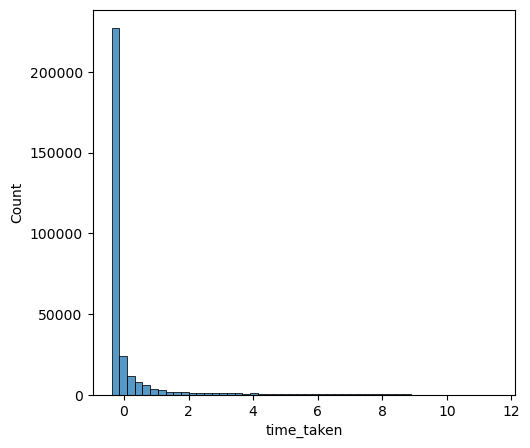

In [671]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(closed_requests['time_taken'], bins=50)
plt.show()

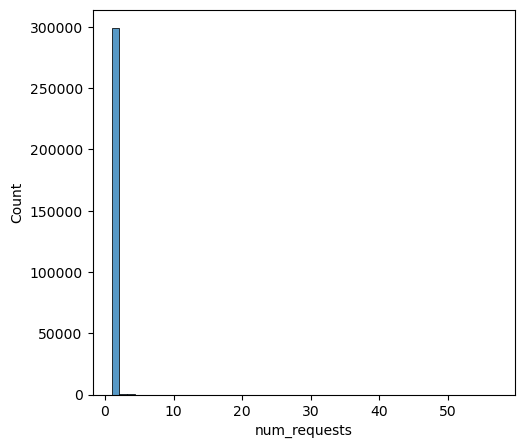

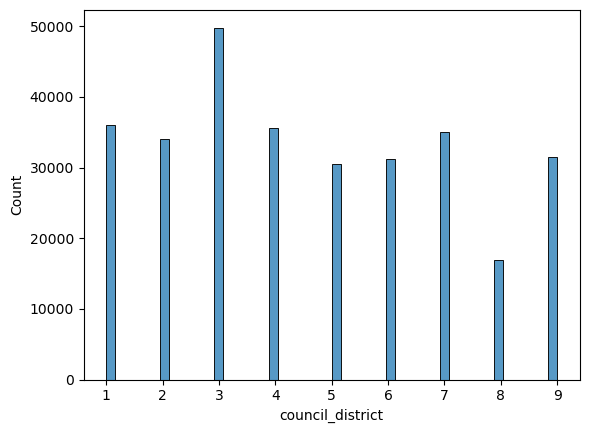

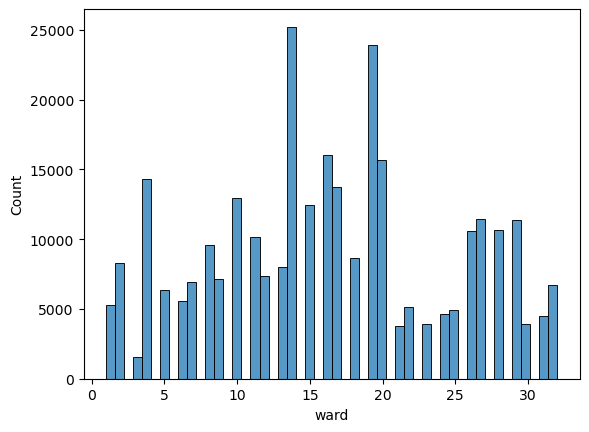

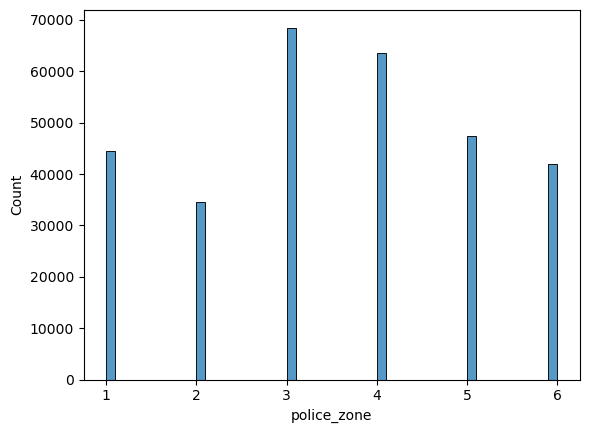

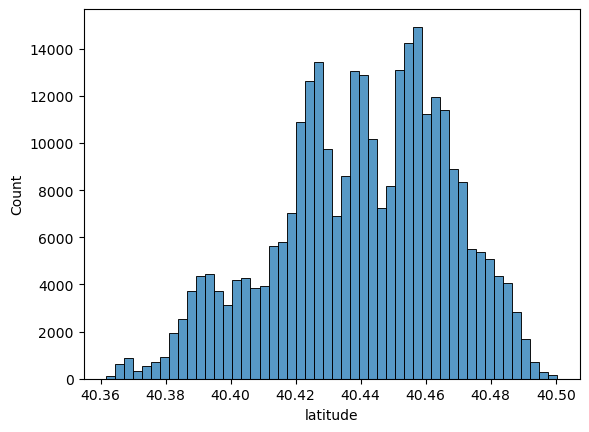

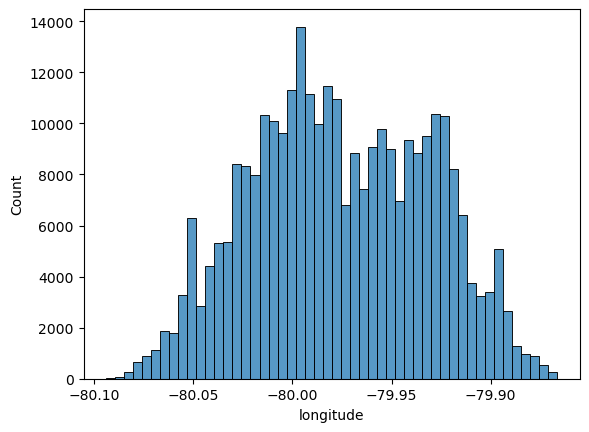

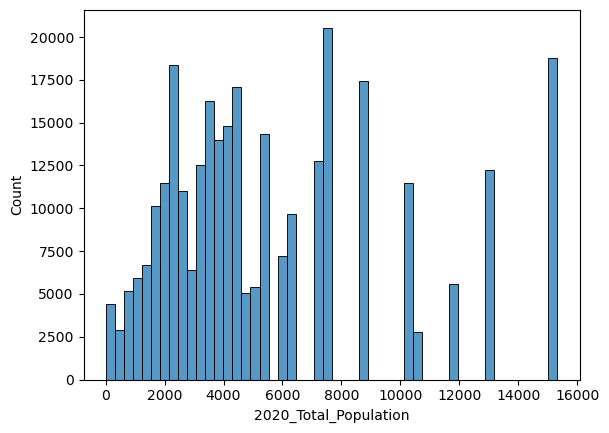

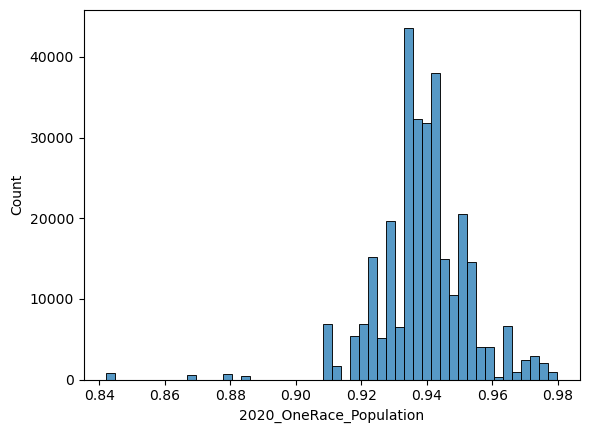

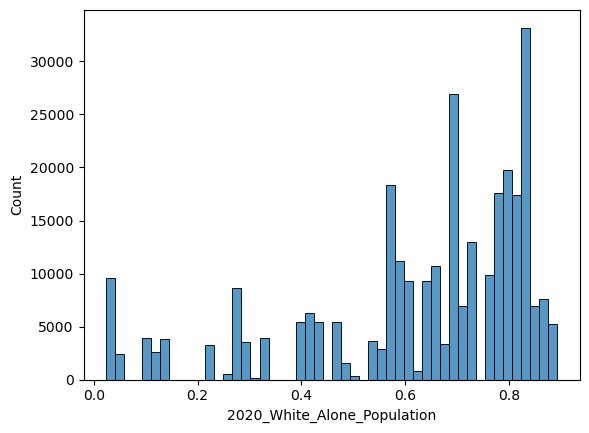

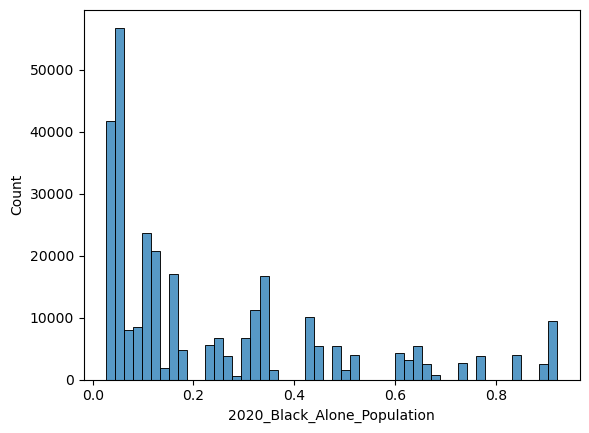

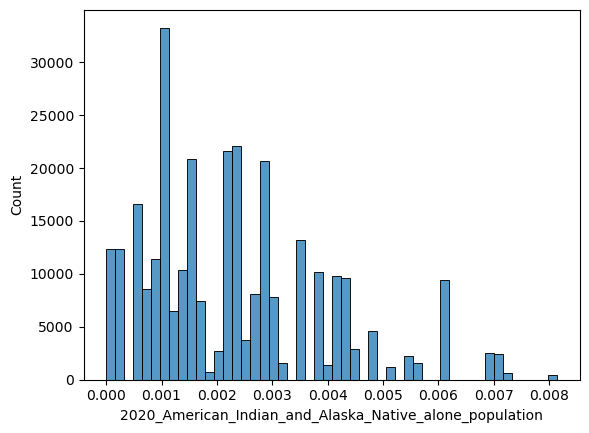

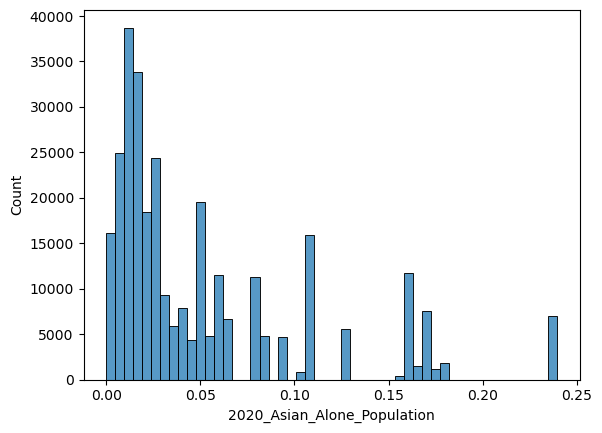

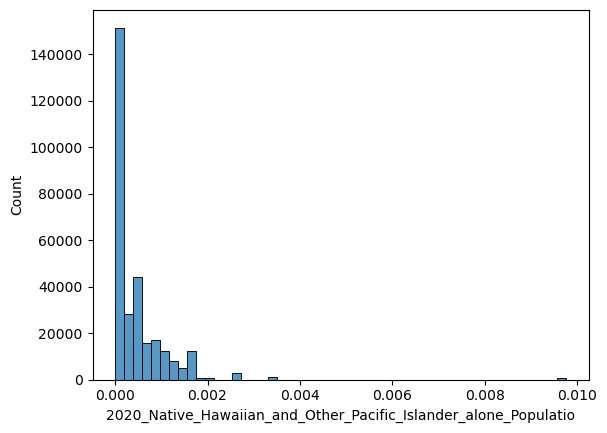

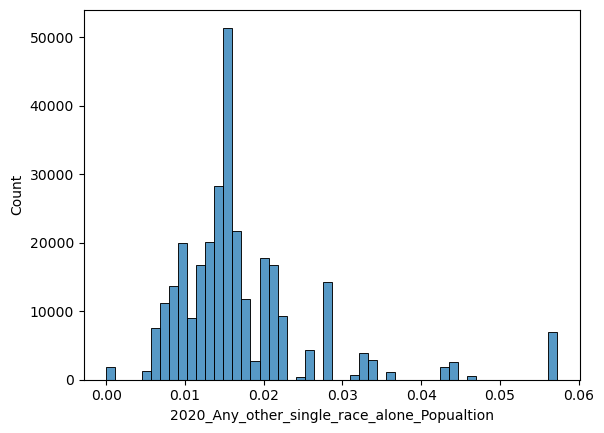

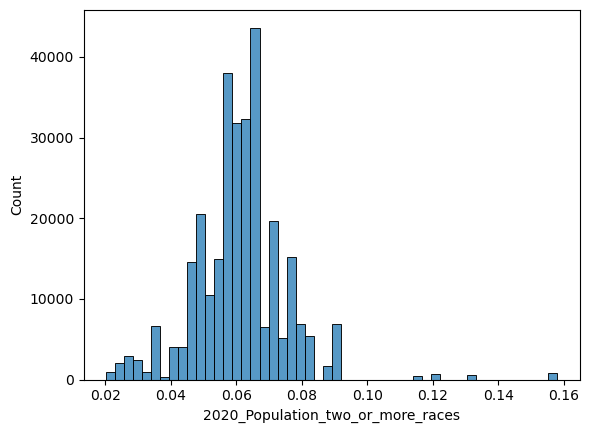

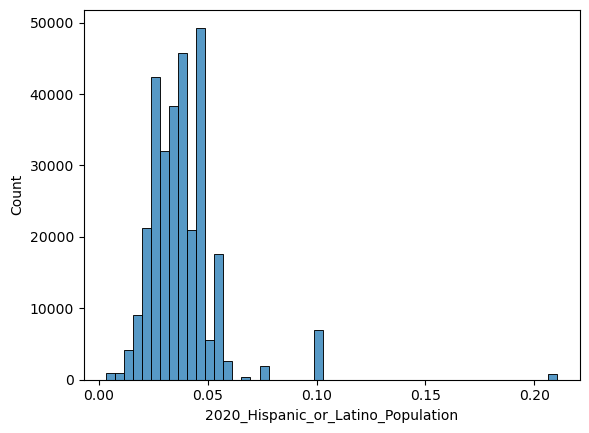

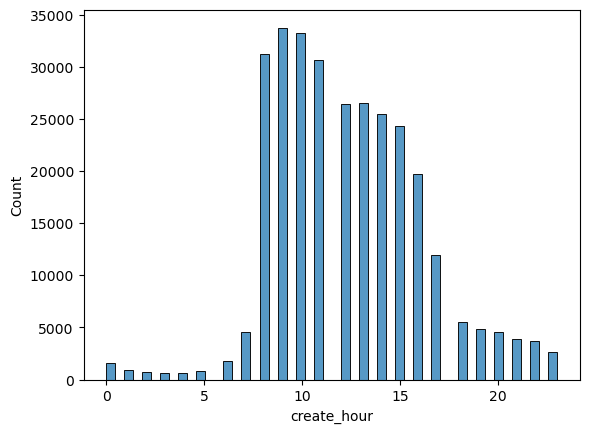

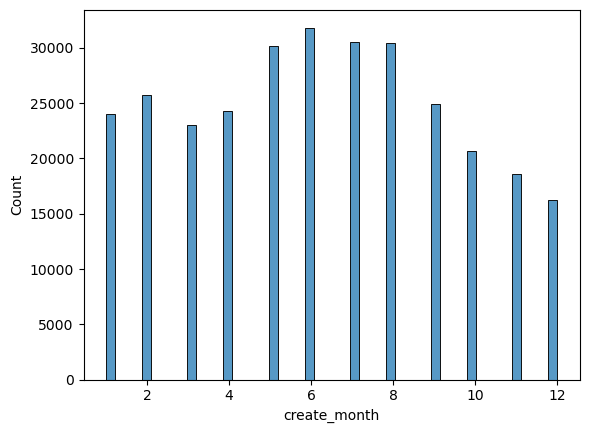

In [675]:
plt.figure(figsize=(12,5))
plt.subplot(121)
for i in ['num_requests', 'council_district', 'ward', 'police_zone', 'latitude', 'longitude', '2020_Total_Population', '2020_OneRace_Population', '2020_White_Alone_Population', '2020_Black_Alone_Population', '2020_American_Indian_and_Alaska_Native_alone_population', '2020_Asian_Alone_Population', '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio', '2020_Any_other_single_race_alone_Popualtion', '2020_Population_two_or_more_races', '2020_Hispanic_or_Latino_Population', 'create_hour', 'create_month']:
    sns.histplot(closed_requests[i], bins=50)
    plt.show()

# linear regression

## (1) Cross validation

In [670]:
from sklearn.model_selection import cross_validate, TimeSeriesSplit

def regression_metrics(y_true, y_pred):
    metrics = {
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
    }
    
    return metrics

def cross_val_with_metrics(model, X, y, cv):
    fold_results = []
    
    for train_idx, test_idx in cv.split(X):
        # 分割数据
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测
        y_pred = model.predict(X_test)
        
        # 计算指标
        metrics = regression_metrics(y_test, y_pred)
        fold_results.append(metrics)
    
    return pd.DataFrame(fold_results)

In [676]:
X = closed_requests.drop(columns=['time_taken','create_date_et','closed_date_et'])
y = closed_requests['time_taken']
model = LinearRegression()
cv = TimeSeriesSplit(n_splits=5)

results_df = cross_val_with_metrics(model, X, y, cv)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

In [677]:
print("cross validation :\n", results_df.mean().to_frame().T)

cross validation :
          R²      RMSE       MAE
0 -0.658186  0.871724  0.499119


In [678]:
# 输出结果
print("performance of each fold:")
print(results_df)
print("\nmean:")
print(results_df.mean().to_frame().T)

performance of each fold:
         R²      RMSE       MAE
0  0.193873  1.094651  0.554248
1  0.041113  1.155786  0.643765
2  0.011592  0.807864  0.498572
3 -0.605981  0.708275  0.433936
4 -2.931526  0.592042  0.365076

mean:
         R²      RMSE       MAE
0 -0.658186  0.871724  0.499119


In [ ]:
final_model = LinearRegression().fit(X, y)
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': final_model.coef_,
    'abs_coef': np.abs(final_model.coef_)
}).sort_values('abs_coef', ascending=False)

In [684]:
print("\n rank:")
print(coef_df.tail(50))


 rank:
                                               feature   coefficient  \
78                              neighborhood_Fairywood -3.199131e-02   
24                                      origin_Website  3.129462e-02   
79                               neighborhood_Fineview  3.080983e-02   
96                     neighborhood_Marshall-Shadeland -3.059878e-02   
127                           neighborhood_Summer Hill -2.936769e-02   
214                           category_PPA Parking Lot -2.882035e-02   
36                                   city_McKees Rocks  2.841885e-02   
94                    neighborhood_Lower Lawrenceville -2.833752e-02   
31                                        city_Crafton -2.814804e-02   
62                                neighborhood_Carrick -2.742487e-02   
130                             neighborhood_Troy Hill  2.575187e-02   
17                                origin_Control Panel  2.491694e-02   
58                                neighborhood_Bon Air  

## (2) Rolling

In [685]:
class RollingWindowSplit:
    def __init__(self, n_splits=5, window_size=365*3, test_size=365):
        self.n_splits = n_splits
        self.window_size = window_size
        self.test_size = test_size
    
    def split(self, X):
        n_samples = len(X)
        for i in range(self.n_splits):
            train_start = i * self.test_size
            train_end = train_start + self.window_size
            test_end = train_end + self.test_size
            
            if test_end > n_samples:
                break
                
            yield (
                np.arange(train_start, train_end),
                np.arange(train_end, test_end)
            )

def cross_val_with_metrics(model, X, y, cv):
    fold_results = []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
        # 分割数据
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测
        y_pred = model.predict(X_test)
        
        # 计算指标
        metrics = {
            'R²': r2_score(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred)
        }
        fold_results.append(metrics)
    
    return pd.DataFrame(fold_results)

In [686]:
X = closed_requests.drop(columns=['time_taken','create_date_et','closed_date_et'])
y = closed_requests['time_taken']

model = LinearRegression()
cv = RollingWindowSplit(n_splits=5, window_size=365*3, test_size=365)  # 3年训练，1年测试

# 执行交叉验证
results_df = cross_val_with_metrics(model, X, y, cv)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

In [687]:
# 输出结果
print("performance:")
print(results_df)
print("\nmean:")
print(results_df.mean().to_frame().T)


performance:
         R²      RMSE       MAE
0  0.124346  1.416994  0.820443
1  0.001995  1.369786  0.752316
2 -0.308964  1.318373  0.729148
3  0.111231  1.492636  0.715411
4  0.094625  1.533412  0.778980

mean:
         R²     RMSE      MAE
0  0.004647  1.42624  0.75926


In [ ]:
final_model = LinearRegression()
final_model.fit(X, y)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': final_model.coef_,
    'abs_coef': np.abs(final_model.coef_)
}).sort_values('abs_coef', ascending=False)

In [689]:
print("\nrank:")
print(coef_df.tail())


rank:
                                           feature   coefficient      abs_coef
199                             category_Land Bank  6.661338e-15  6.661338e-15
244     category_Scoobi (Sit-Down Scooter) Parking  3.386180e-15  3.386180e-15
251                        category_Special Events  3.330669e-15  3.330669e-15
302                         dept_simplified_Scoobi  0.000000e+00  0.000000e+00
303  dept_simplified_Urban Redevelopment Authority  0.000000e+00  0.000000e+00


In [753]:
# 定义要测试的分位阈值范围
quantiles = np.arange(0.1, 1.0, 0.05)  # 从0.1到0.95，步长0.05

# 存储结果的容器
results = []

# 主循环
for q in quantiles:
    # 1. 特征筛选
    threshold = coef_df['abs_coef'].quantile(q)
    significant_features = coef_df[coef_df['abs_coef'] > threshold]['feature']
    X_filtered = X[significant_features]
    
    # 2. 交叉验证
    model = LinearRegression()  # 每次循环新建模型
    cv = RollingWindowSplit(n_splits=5, window_size=365*3, test_size=365)
    results_df = cross_val_with_metrics(model, X_filtered, y, cv)
    
    # 3. 记录结果
    results.append({
        'quantile': q,
        'num_features': len(significant_features),
        'mean_R2': results_df['R²'].mean(),
        'mean_RMSE': results_df['RMSE'].mean(),
        'mean_MAE': results_df['MAE'].mean()
    })

# 转换为DataFrame并分析
results_df = pd.DataFrame(results).sort_values('mean_R2', ascending=False)

# 找到最佳分位值
best_q = results_df.iloc[0]['quantile']

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

optimal: 0.55
optimal result:
    quantile  num_features   mean_R2  mean_RMSE  mean_MAE
9       0.55           138  0.104873   1.359762  0.644237
10      0.60           123  0.099906   1.363217  0.648741
8       0.50           153  0.084056   1.374045  0.654904


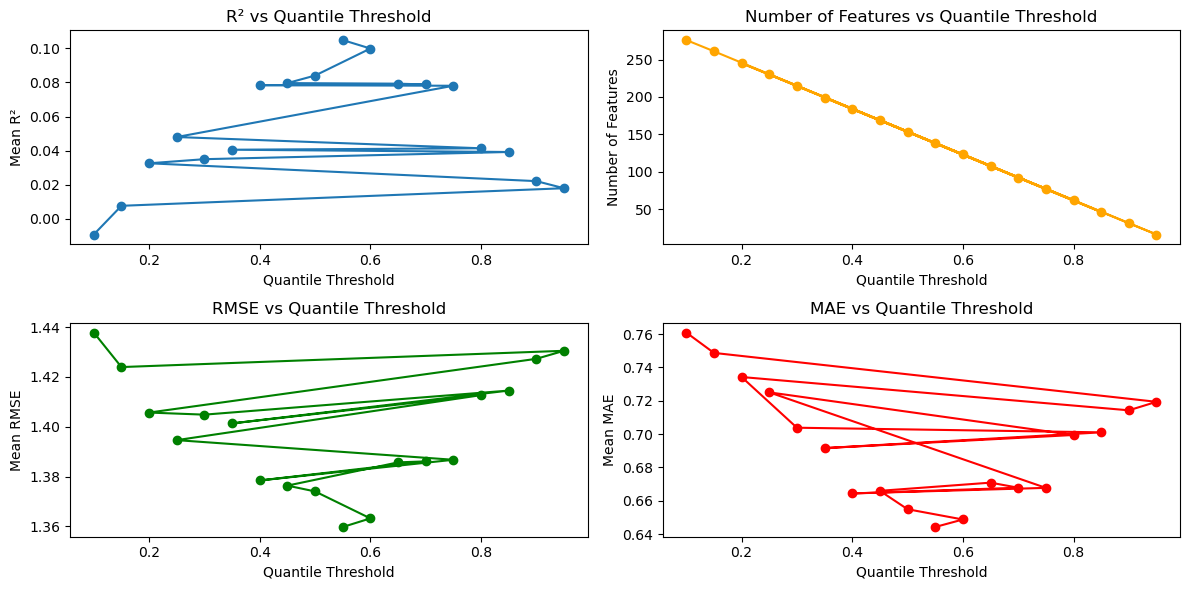

In [755]:
print(f"optimal: {best_q:.2f}")
print("optimal result:")
print(results_df.head(3))

# 可视化分析
plt.figure(figsize=(12, 6))

# R²趋势
plt.subplot(2, 2, 1)
plt.plot(results_df['quantile'], results_df['mean_R2'], marker='o')
plt.title('R² vs Quantile Threshold')
plt.xlabel('Quantile Threshold')
plt.ylabel('Mean R²')

# 特征数量趋势
plt.subplot(2, 2, 2)
plt.plot(results_df['quantile'], results_df['num_features'], marker='o', color='orange')
plt.title('Number of Features vs Quantile Threshold')
plt.xlabel('Quantile Threshold')
plt.ylabel('Number of Features')

# RMSE趋势
plt.subplot(2, 2, 3)
plt.plot(results_df['quantile'], results_df['mean_RMSE'], marker='o', color='green')
plt.title('RMSE vs Quantile Threshold')
plt.xlabel('Quantile Threshold')
plt.ylabel('Mean RMSE')

# MAE趋势
plt.subplot(2, 2, 4)
plt.plot(results_df['quantile'], results_df['mean_MAE'], marker='o', color='red')
plt.title('MAE vs Quantile Threshold')
plt.xlabel('Quantile Threshold')
plt.ylabel('Mean MAE')

plt.tight_layout()
plt.show()

In [756]:
threshold = coef_df['abs_coef'].quantile(0.55)
significant_features = coef_df[coef_df['abs_coef'] > threshold]['feature']

In [757]:
X_filtered = X[significant_features]

In [758]:
model = LinearRegression()
cv = RollingWindowSplit(n_splits=5, window_size=365*3, test_size=365)  # 3年训练，1年测试

# 执行交叉验证
results_df = cross_val_with_metrics(model, X_filtered, y, cv)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

In [759]:
print("performance:")
print(results_df)
print("\nmean:")
print(results_df.mean().to_frame().T)

performance:
         R²      RMSE       MAE
0  0.216374  1.340467  0.688454
1  0.109487  1.293917  0.679172
2 -0.071033  1.192547  0.571777
3  0.146091  1.463070  0.629619
4  0.123446  1.508808  0.652163

mean:
         R²      RMSE       MAE
0  0.104873  1.359762  0.644237


# Lasson

In [763]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

def cross_val_lasso(X_data, y_data, cv):
    fold_results = []
    feature_counts = []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_data)):
        # 分割数据
        X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]
        
        # 标准化（仅在训练集拟合）
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # LassoCV自动选择alpha
        lasso = LassoCV(
            alphas=np.logspace(-6, 3, 100),  # 扩展alpha范围
            cv=TimeSeriesSplit(n_splits=10),
            max_iter=10000,
            tol=1e-5,
            random_state=42
        )
        lasso.fit(X_train_scaled, y_train)
        
        # 预测
        y_pred = lasso.predict(X_test_scaled)
        
        # 记录结果
        metrics = {
            'R²': r2_score(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'num_features': np.sum(lasso.coef_ != 0)
        }
        fold_results.append(metrics)
    
    return pd.DataFrame(fold_results)

In [764]:
cv = RollingWindowSplit(n_splits=5, window_size=365*3, test_size=365)

In [765]:
results_full = cross_val_lasso(X, y, cv)
print("\nperformance:")
print(results_full)
print("\nmean:")
print(results_full.mean().to_frame().T)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  if np.may_share_memory(array, array_orig):
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_val


performance:
         R²      RMSE       MAE  num_features
0  0.014621  1.503154  0.839787             3
1  0.061750  1.328145  0.689286            19
2 -0.013829  1.160263  0.647288             2
3  0.021291  1.566341  0.743856             1
4  0.059182  1.563139  0.713151             7

mean:
         R²      RMSE       MAE  num_features
0  0.028603  1.424208  0.726674           6.4


E:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.04475948380331829, tolerance: 0.018344983844404972
  model = cd_fast.enet_coordinate_descent_gram(


In [772]:
def cross_val_lasso(X_data, y_data, cv):
    fold_results = []
    feature_counts = []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_data)):
        # 分割数据
        X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]
        
        # 标准化（仅在训练集拟合）
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # LassoCV自动选择alpha
        lasso = LassoCV(
            alphas=np.logspace(-6, 1, 100),  # 扩展alpha范围
            cv=TimeSeriesSplit(n_splits=10),
            max_iter=10000,
            tol=1e-5,
            random_state=42
        )
        lasso.fit(X_train_scaled, y_train)
        
        # 预测
        y_pred = lasso.predict(X_test_scaled)
        
        # 记录结果
        metrics = {
            'R²': r2_score(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'num_features': np.sum(lasso.coef_ != 0)
        }
        fold_results.append(metrics)
    
    return pd.DataFrame(fold_results)


cv = RollingWindowSplit(n_splits=5, window_size=365*3, test_size=365)
results_full2 = cross_val_lasso(X, y, cv)
print("\nperformance:")
print(results_full2)
print("\nmean:")
print(results_full2.mean().to_frame().T)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  if np.may_share_memory(array, array_orig):
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_val


performance:
         R²      RMSE       MAE  num_features
0  0.002980  1.512007  0.845224             1
1  0.062549  1.327579  0.691107            16
2 -0.014237  1.160497  0.647123             2
3  0.009660  1.575620  0.752786             1
4  0.062023  1.560777  0.710910             7

mean:
         R²      RMSE      MAE  num_features
0  0.024595  1.427296  0.72943           5.4


In [773]:
results_filtered = cross_val_lasso(X_filtered, y, cv)
print("\n performance:")
print(results_filtered)
print("\n mean:")
print(results_filtered.mean().to_frame().T)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  if np.may_share_memory(array, array_orig):
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_val


 performance:
         R²      RMSE       MAE  num_features
0 -0.000492  1.514637  0.847329             0
1  0.110989  1.292825  0.673934            20
2 -0.027261  1.167924  0.583263            19
3  0.144973  1.464028  0.640748            19
4  0.110038  1.520304  0.658638            29

 mean:
         R²      RMSE       MAE  num_features
0  0.067649  1.391944  0.680782          17.4


# RF

In [783]:
from sklearn.model_selection import GridSearchCV

class RollingWindowSplit2:
    def __init__(self, n_splits=5, window_size=365*3, test_size=365):
        self.n_splits = n_splits
        self.window_size = window_size
        self.test_size = test_size
        
    def split(self, X, y=None, groups=None):  # 关键修正：添加y和groups参数
        n_samples = len(X)
        for i in range(self.n_splits):
            train_start = i * self.test_size
            train_end = train_start + self.window_size
            test_end = train_end + self.test_size
            
            if test_end > n_samples:
                break
                
            yield (
                np.arange(train_start, train_end),
                np.arange(train_end, test_end)
            )
    
    def get_n_splits(self, X=None, y=None, groups=None):  # 修正参数签名
        return self.n_splits

cv = RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365)

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 0.8]
}

In [784]:
# 测试split接口
for train_idx, test_idx in cv.split(X, y, groups=None):  # 模拟GridSearchCV调用方式
    print(f"train size: {len(train_idx)}, test size: {len(test_idx)}")

# 集成到GridSearchCV
rf_tuned = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    verbose=2
)
rf_tuned.fit(X, y)

train size: 1095, test size: 365
train size: 1095, test size: 365
train size: 1095, test size: 365
train size: 1095, test size: 365
train size: 1095, test size: 365
Fitting 5 folds for each of 24 candidates, totalling 120 fits


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.6s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.8s


...

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   8.4s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   8.1s


GridSearchCV(cv=<__main__.RollingWindowSplit2 object at 0x000001A8BB851100>,
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 0.8],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [803]:
print("optimal parameters:", rf_tuned.best_params_)

optimal parameters: {'max_depth': None, 'max_features': 0.8, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
# 最佳参数模型
best_model = rf_tuned.best_estimator_

# 重新运行时间滚动交叉验证
cv = RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365)
results = cross_val_with_metrics(best_model, X, y, cv)


In [791]:
print("performance:")
print(results)
print("\nmean:")
print(results.mean().to_frame().T)


performance:
         R²      RMSE       MAE
0  0.165307  1.383456  0.695545
1  0.098895  1.301589  0.639542
2 -0.064846  1.189098  0.541083
3  0.146572  1.462659  0.618952
4  0.228419  1.415583  0.590538

mean:
         R²      RMSE       MAE
0  0.114869  1.350477  0.617132


In [794]:
importances = best_model.feature_importances_

# 转换为DataFrame并排序
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance.tail(40))

                                       feature  importance
191             category_Graffiti on Structure         0.0
192                 category_Grate, Stormwater         0.0
193                         category_Greenways         0.0
195   category_Handicap Parking Signs, Removal         0.0
198  category_Junk Vehicles (Private Property)         0.0
199                         category_Land Bank         0.0
200                       category_Lead Safety         0.0
201                  category_Lead Testing Kit         0.0
203                      category_MO Escalated         0.0
204          category_Misconduct/City Employee         0.0
207                     category_Missing Grate         0.0
208                category_Need Potable Water         0.0
210                             category_Other         0.0
211         category_Outdoor Retail and Dining         0.0
212                 category_Overgrowth, Parks         0.0
213                               category_PAT         0

In [797]:
feature_importance.shape

(307, 2)

In [801]:
feature_importance[feature_importance['importance'] > 0.01].shape

(25, 2)

In [798]:
# 选择重要性>0.01的特征
selected_features = feature_importance[feature_importance['importance'] > 0.01]['feature']
X_filtered_rf = X[selected_features]

In [799]:
X_filtered_rf.shape

(300510, 25)

In [802]:
# 集成到GridSearchCV
rf_tuned2 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    verbose=2
)
rf_tuned2.fit(X_filtered, y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.4s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.3s


...

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   1.9s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   1.9s


GridSearchCV(cv=<__main__.RollingWindowSplit2 object at 0x000001A8BB7C7E30>,
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 0.8],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [804]:
# 最佳参数模型
best_model2 = rf_tuned2.best_estimator_

# 重新运行时间滚动交叉验证
cv = RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365)
results2 = cross_val_with_metrics(best_model2, X_filtered, y, cv)

print("performance:")
print(results2)
print("\nmean:")
print(results2.mean().to_frame().T)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

performance:
         R²      RMSE       MAE
0  0.183393  1.368385  0.729659
1  0.125013  1.282588  0.688770
2  0.028207  1.135955  0.591403
3  0.172485  1.440282  0.631618
4  0.224562  1.419117  0.611393

mean:
         R²      RMSE       MAE
0  0.146732  1.329265  0.650568


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [805]:
rf_tuned3 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    verbose=2
)
rf_tuned3.fit(X_filtered_rf, y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.4s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.4s


...

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   2.9s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   2.7s


GridSearchCV(cv=<__main__.RollingWindowSplit2 object at 0x000001A8C5B2B9E0>,
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 0.8],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [806]:
# 最佳参数模型
best_model3 = rf_tuned3.best_estimator_

# 重新运行时间滚动交叉验证
cv = RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365)
results3 = cross_val_with_metrics(best_model3, X_filtered_rf, y, cv)

print("performance:")
print(results3)
print("\nmean:")
print(results3.mean().to_frame().T)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

performance:
         R²      RMSE       MAE
0  0.113642  1.425629  0.793120
1  0.148886  1.264970  0.694612
2  0.012088  1.145337  0.624574
3  0.193851  1.421566  0.653132
4  0.173471  1.465122  0.639799

mean:
         R²      RMSE       MAE
0  0.128387  1.344525  0.681047


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [807]:
threshold_options = {
    'method': 'quantile',  # 可选 'fixed' 或 'quantile'
    'values': [0.5, 0.6, 0.7, 0.8, 0.9]  # 分位数或固定阈值列表
}

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 0.8]
}

results = []
best_config = {
    'threshold': None,
    'model': None,
    'features': None,
    'performance': None
}

for value in threshold_options['values']:
    # 特征筛选
    if threshold_options['method'] == 'quantile':
        threshold = feature_importance['importance'].quantile(value)
        selected_features = feature_importance[feature_importance['importance'] > threshold]['feature']
    else:
        selected_features = feature_importance[feature_importance['importance'] > value]['feature']
    
    X_filtered = X[selected_features]
    
    # 跳过空特征集
    if X_filtered.shape[1] == 0:
        print(f"skip {value}：no feature")
        continue
    
    # 网格搜索调参
    rf_tuned = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42),
        param_grid=param_grid,
        cv=RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365),
        scoring='neg_root_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )
    rf_tuned.fit(X_filtered, y)
    
    # 交叉验证评估
    best_model = rf_tuned.best_estimator_
    cv_results = cross_val_with_metrics(best_model, X_filtered, y, 
                                       RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365))
    mean_metrics = cv_results.mean().to_dict()
    
    # 记录结果
    results.append({
        'threshold_value': value,
        'threshold_type': threshold_options['method'],
        'num_features': X_filtered.shape[1],
        **mean_metrics
    })
    
    # 更新最佳配置
    if best_config['performance'] is None or mean_metrics['R²'] > best_config['performance']['R²']:
        best_config.update({
            'threshold': value,
            'model': best_model,
            'features': X_filtered.columns.tolist(),
            'performance': mean_metrics
        })

# ====================
# 结果输出
# ====================
results_df = pd.DataFrame(results)
print("comparison:")
print(results_df.sort_values('R²', ascending=False))

print("\noptimal:")
print(f"method: {threshold_options['method']}")
print(f"value: {best_config['threshold']}")
print(f"# of features: {len(best_config['features'])}")
print(f"mean R²: {best_config['performance']['R²']:.3f}")
print(f"features remained: {best_config['features'][:5]}")

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

comparison:
   threshold_value threshold_type  num_features        R²      RMSE       MAE
4              0.9       quantile            31  0.134159  1.340892  0.677981
2              0.7       quantile            92  0.128099  1.346084  0.683509
1              0.6       quantile           123  0.125488  1.348868  0.669023
3              0.8       quantile            62  0.121305  1.351866  0.686594
0              0.5       quantile           153  0.112472  1.352406  0.623989

optimal:
method: quantile
value: 0.9
# of features: 31
mean R²: 0.134
features remained: ['longitude', 'latitude', 'category_Garbage and Litter Issues', 'create_hour', '2020_Total_Population']


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


<Figure size 1200x600 with 0 Axes>

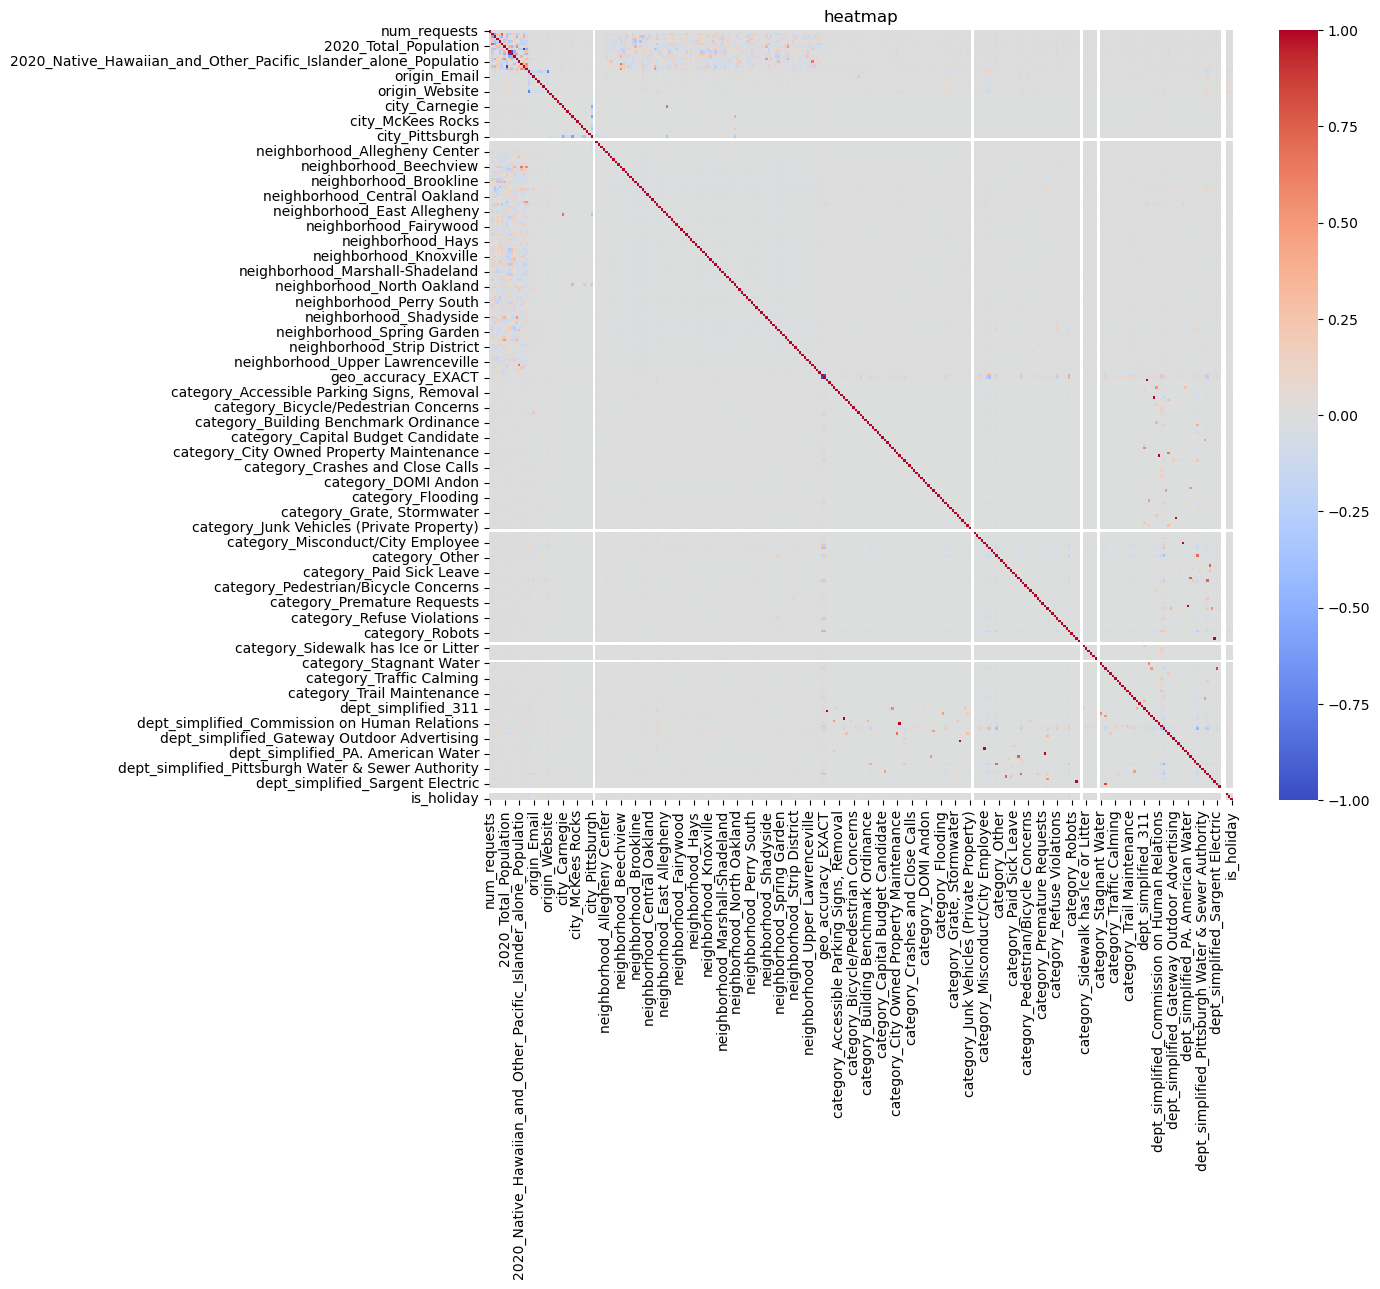

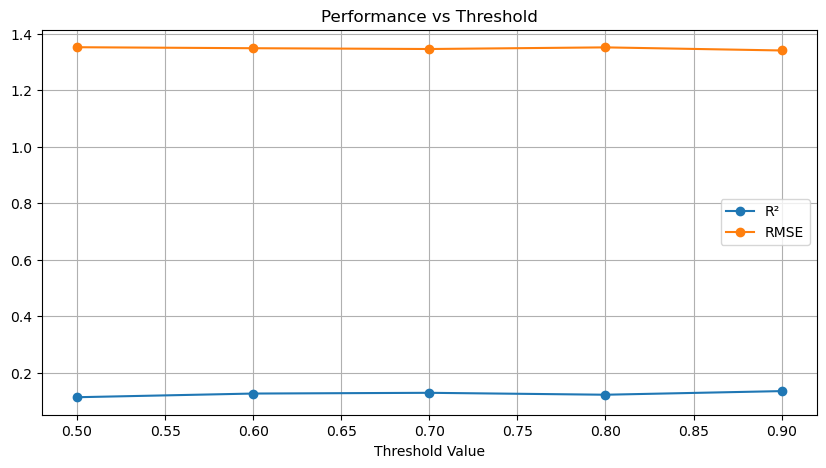

In [808]:
plt.figure(figsize=(10,5))
plt.plot(results_df['threshold_value'], results_df['R²'], marker='o', label='R²')
plt.plot(results_df['threshold_value'], results_df['RMSE'], marker='o', label='RMSE')
plt.xlabel('Threshold Value')
plt.title('Performance vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


# XGBoost

In [809]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

def xgb_cross_val(X, y, cv, param_grid=None):
    fold_results = []
    feature_importances = []
    
    # 默认参数
    default_params = {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # 初始化模型（使用参数网格或默认参数）
        if param_grid:
            model = GridSearchCV(
                XGBRegressor(**default_params),
                param_grid,
                cv=3,
                scoring='neg_mean_squared_error'
            )
            model.fit(X_train, y_train)
            best_model = model.best_estimator_
        else:
            best_model = XGBRegressor(**default_params).fit(X_train, y_train)
        
        # 预测与评估
        y_pred = best_model.predict(X_test)
        fold_results.append({
            'R²': r2_score(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred)
        })
        
        # 记录特征重要性
        importances = best_model.feature_importances_
        feature_importances.append(pd.Series(importances, index=X.columns))
    
    # 合并特征重要性
    importance_df = pd.concat(feature_importances, axis=1).mean(axis=1)
    return pd.DataFrame(fold_results), importance_df

In [810]:
cv = RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365)

# 参数网格（示例）
param_grid = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8]
}

# 执行交叉验证与参数调优
results_df, importance_df = xgb_cross_val(X, y, cv, param_grid)

E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: S

In [811]:
print("performance:")
print(results_df)
print("\nmean:")
print(results_df.mean().to_frame().T)

performance:
         R²      RMSE       MAE
0  0.178843  1.372192  0.708883
1  0.164819  1.253074  0.628761
2  0.008559  1.147382  0.559291
3  0.177764  1.435680  0.639124
4  0.150830  1.485053  0.620718

mean:
         R²      RMSE       MAE
0  0.136163  1.338676  0.631355


In [814]:
importance_df.sort_values().head(40)

category_Robots                                   0.0
neighborhood_West Oakland                         0.0
neighborhood_Westwood                             0.0
category_Paid Sick Leave                          0.0
category_Taxes                                    0.0
category_Street Light Repair                      0.0
category_911 Performance                          0.0
category_ADA Ramp, Installation                   0.0
category_Abandoned Vehicle                        0.0
category_Accessibility                            0.0
category_Thank you - DPW                          0.0
category_Accessible Parking Application           0.0
category_Angle Iron                               0.0
category_Storm Damage                             0.0
category_Ask Us/General FAQs                      0.0
category_Ballfield                                0.0
category_Bicycle Parking                          0.0
category_Bicycle/Pedestrian Concerns              0.0
category_Blocked or Closed S

In [815]:
# 执行交叉验证与参数调优
results_df2, importance_df2 = xgb_cross_val(X_filtered, y, cv, param_grid)

E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: S

In [816]:
print("performance:")
print(results_df2)
print("\nmean:")
print(results_df2.mean().to_frame().T)

performance:
         R²      RMSE       MAE
0  0.070573  1.459854  0.764526
1  0.163469  1.254086  0.661577
2 -0.054531  1.183325  0.602571
3  0.190670  1.424368  0.627252
4  0.154060  1.482226  0.620153

mean:
         R²      RMSE       MAE
0  0.104848  1.360772  0.655216


In [818]:
from sklearn.feature_selection import SelectFromModel

threshold_options = {
    'method': 'quantile', 
    'values': [0.5, 0.6, 0.7, 0.8, 0.9]  # 分位数或固定阈值
}

xgb_param_grid = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8]
}


results = []
best_config = {
    'threshold': None,
    'model': None,
    'features': None,
    'performance': None
}

# 先训练全量模型获取全局特征重要性
base_model = XGBRegressor(n_estimators=100, random_state=42)
base_model.fit(X, y)
global_importance = pd.Series(base_model.feature_importances_, index=X.columns)

for value in threshold_options['values']:
    # 特征筛选
    if threshold_options['method'] == 'quantile':
        threshold = global_importance.quantile(value)
    else:
        threshold = value
    
    # 使用SelectFromModel筛选特征
    selector = SelectFromModel(base_model, threshold=threshold, prefit=True)
    X_filtered = pd.DataFrame(selector.transform(X), columns=X.columns[selector.get_support()])
    
    # 跳过空特征集
    if X_filtered.shape[1] == 0:
        print(f"skip {value}: no feature selected")
        continue
    
    # 网格搜索调优
    xgb = XGBRegressor(n_estimators=1000, random_state=42)
    grid_search = GridSearchCV(
        xgb,
        xgb_param_grid,
        cv=RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365),
        scoring='neg_root_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )
    grid_search.fit(X_filtered, y)
    
    # 交叉验证评估
    best_model = grid_search.best_estimator_
    cv_results = cross_val_with_metrics(best_model, X_filtered, y, 
                                      RollingWindowSplit2(n_splits=5, window_size=365*3, test_size=365))
    mean_metrics = cv_results.mean().to_dict()
    
    # 记录结果
    results.append({
        'threshold_value': value,
        'threshold_type': threshold_options['method'],
        'num_features': X_filtered.shape[1],
        **mean_metrics
    })
    
    # 更新最佳配置
    if best_config['performance'] is None or mean_metrics['R²'] > best_config['performance']['R²']:
        best_config.update({
            'threshold': value,
            'model': best_model,
            'features': X_filtered.columns.tolist(),
            'performance': mean_metrics
        })

E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromMod

In [819]:
results_df = pd.DataFrame(results)
print("comparison:")
print(results_df.sort_values('R²', ascending=False))

print("\noptimal:")
print(f"method: {threshold_options['method']}")
print(f"threshold: {best_config['threshold']}")
print(f"# of features: {len(best_config['features'])}")
print(f"mean R²: {best_config['performance']['R²']:.3f}")
print(f"importance features examples: {best_config['features'][:5]}")

comparison:
   threshold_value threshold_type  num_features        R²      RMSE       MAE
0              0.5       quantile           154  0.036473  1.406413  0.680673
2              0.7       quantile            92  0.028768  1.408568  0.674845
1              0.6       quantile           123  0.025113  1.413738  0.702294
3              0.8       quantile            62  0.019360  1.413442  0.678786
4              0.9       quantile            31 -0.087173  1.489004  0.667988

optimal:
method: quantile
threshold: 0.5
# of features: 154
mean R²: 0.036
importance features examples: ['num_requests', 'council_district', 'ward', 'police_zone', 'latitude']


### One hot encoding

In [206]:
# Encoding parent_closed
cleaned_data['parent_closed'] = cleaned_data['parent_closed'].replace({'t': 1, 'f': 0})

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2748\3239735795.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_data['parent_closed'] = cleaned_data['parent_closed'].replace({'t': 1, 'f': 0})


In [208]:
cleaned_data.isnull().sum()

_id                     0
group_id                0
num_requests            0
parent_closed           0
status_name             0
status_code             0
create_date_et          0
last_action_et          0
closed_date_et      83200
origin                  0
city                    0
neighborhood            0
council_district        0
ward                    0
police_zone             0
geo_accuracy            0
category                0
dept_simplified         0
dtype: int64

# Time

In [283]:
data = cleaned_data

In [284]:
data = data.sort_values(by='create_date_et', ascending=True)

In [285]:
data['create_date_et']

151382   2015-04-20 07:37:00
196183   2015-04-20 07:40:00
111096   2015-04-20 07:41:00
413448   2015-04-20 07:46:00
413689   2015-04-20 07:47:00
                 ...        
799997   2024-12-18 09:28:00
799994   2024-12-18 09:32:00
799993   2024-12-18 09:39:00
799990   2024-12-18 09:40:00
799999   2024-12-18 09:41:00
Name: create_date_et, Length: 759673, dtype: datetime64[ns]

In [286]:
closed_requests = data[data['closed_date_et'].notna()].copy()
open_requests = data[data['closed_date_et'].isna()].copy()

In [287]:
data.shape

(759673, 18)

In [288]:
data.columns

Index(['_id', 'group_id', 'num_requests', 'parent_closed', 'status_name',
       'status_code', 'create_date_et', 'last_action_et', 'closed_date_et',
       'origin', 'city', 'neighborhood', 'council_district', 'ward',
       'police_zone', 'geo_accuracy', 'category', 'dept_simplified'],
      dtype='object')

# ↓到这里

In [292]:
print(closed_requests.shape,closed_requests.shape[0]/800000)
print(open_requests.shape,open_requests.shape[0]/800000)

(676473, 18) 0.84559125
(83200, 18) 0.104


### i. Non-closed request

In [293]:
status_dist = open_requests['status_name'].value_counts(normalize=True).mul(100).round(2)
print(f"status distribution（%）:\n{status_dist.to_string()}")

status distribution（%）:
status_name
in progress    54.35
open           45.10
on hold         0.55


In [294]:
for status in ['open', 'in progress', 'on hold']:
    status_subset = open_requests[open_requests['status_name'] == status]
    top_types = status_subset['category'].value_counts().head(10)
    print(f"\n{status}: top 10 request types")
    print(top_types.to_string())


open: top 10 request types
category
Parking                                            10512
Public Safety                                       4149
Road/Street Issues                                  3224
In database, but not on 311 Web Submission Form     2243
Dashcam                                             1749
Neighborhood Issues                                 1226
SPIN (Stand Up) Scooters                            1102
City Owned Property Maintenance                      930
Utility Issues                                       863
Parks Issues                                         684

in progress: top 10 request types
category
Neighborhood Issues                                14577
Building Maintenance                                7905
Parking                                             3786
Construction Issues                                 3462
Road/Street Issues                                  2488
Public Safety                                       1651
Tree Is

### ii. Closed request

In [295]:
closed_top = closed_requests['category'].value_counts().head(10)
print(f"closed requests top 10:\n{closed_top.to_string()}")

closed requests top 10:
category
Road/Street Issues           175006
Neighborhood Issues           84963
Missed Refuse Pick Up         39990
Parking                       34030
Building Maintenance          30224
Refuse Violations             25040
Garbage and Litter Issues     23088
Animal Issues                 22639
Tree Issues                   21409
Utility Issues                18594


In [296]:
closed_requests['time_taken'] = (closed_requests['closed_date_et'] - closed_requests['create_date_et']).dt.total_seconds() / 3600/24
closed_requests['time_taken']

151382      9.283333
196183    359.252778
111096     23.118750
413448    877.046528
413689    877.046528
             ...    
799995      2.082639
799997      0.010417
799994      0.749306
799993      2.215278
799999     83.960417
Name: time_taken, Length: 676473, dtype: float64

In [297]:
time_stats = closed_requests.groupby('category')['time_taken'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
).sort_values('mean', ascending=False)

# 显示处理时间最长的类型
print("\n平均处理时间最长的10种请求:")
print(time_stats.head(10).to_string())

# 显示处理时间最短的类型
print("\n平均处理时间最短的10种请求:")
print(time_stats[time_stats['count'] > 50].tail(10).to_string())  # 过滤低频类型

# 异常值检查（超过30天的请求）
long_requests = closed_requests[closed_requests['time_taken'] > 30]  # 30天=720小时
print(f"\n超过30天处理的请求数量: {len(long_requests)}")
print("这些请求的类型分布:")
print(long_requests['category'].value_counts().head(10).to_string())


平均处理时间最长的10种请求:
                                                 count         mean       median          min          max          std
category                                                                                                               
County Maintenance                                   1  1281.039583  1281.039583  1281.039583  1281.039583          NaN
Thank you - DPW                                      1  1226.086806  1226.086806  1226.086806  1226.086806          NaN
Retaining Wall (Public)                            195  1023.947863   224.998611     0.020833  3248.142361  1092.561324
Bicycle/Pedestrian/Trail - Network Improvements      2   936.162847   936.162847   935.116667   937.209028     1.479523
Water Runoff in ROW                                150   787.369273   777.975347     0.000000  1830.750000   505.927893
Sidewalk/Curb/ADA Ramp Maintenance                2323   744.537426   805.122222     0.000000  3529.831250   558.446896
Traffic Signals Surtrac

In [298]:
type_counts2 = closed_requests['category'].value_counts(normalize=True)

# Top 60 High frequency types
type_counts2.head(60)

category
Road/Street Issues                                 0.258704
Neighborhood Issues                                0.125597
Missed Refuse Pick Up                              0.059115
Parking                                            0.050305
Building Maintenance                               0.044679
Refuse Violations                                  0.037016
Garbage and Litter Issues                          0.034130
Animal Issues                                      0.033466
Tree Issues                                        0.031648
Utility Issues                                     0.027487
Street Light                                       0.026680
Construction Issues                                0.025581
Missed Recycling Pick Up                           0.024852
Litter, Public Property                            0.024682
Public Safety                                      0.022954
In database, but not on 311 Web Submission Form    0.017843
Traffic and Street Sign Issues 

## 把category转成了others

In [299]:
threshold = 0.0015
low_freq_types = type_counts2[type_counts2 < threshold].index.tolist()
low_freq_types

['Recycling Questions',
 'Board Up (City-owned property only)',
 'Bicycle/Pedestrian Concerns',
 'Need Potable Water',
 '911 Performance',
 'Pedestrian/Bicycle Concerns',
 'Handicap Parking Signs, Removal',
 'City Cuts Concern',
 'Premature Requests',
 'Graffiti on Structure',
 'Concern',
 'Curb Painting, New',
 'Replace/Repair Sign',
 'Handicapped Parking Application',
 'Trail Maintenance',
 'Vacant Lot',
 'Crosswalk, New',
 'Graffiti in Right of Way',
 'Commission on Human Relations',
 'Signs, Advertising or Political',
 'Recycling Violation',
 'Retaining Wall (Private Property)',
 'Blocked or Closed Trails',
 'Brick or Block Repair',
 'Junk Vehicles (Private Property)',
 'Snow/Ice Removal',
 'Other',
 'PAT',
 'Abandoned Vehicle',
 'Ask Us/General FAQs',
 'Early Trash Set Out',
 'Stagnant Water',
 'Sewage',
 'Christmas Tree',
 'Taxes',
 'Angle Iron',
 'DO NOT USE (Vacant and Open Building)',
 'HACP',
 'Lead Testing Kit',
 'Retaining Wall (Public)',
 'Demolition - DO NOT USE',
 'Bicyc

In [300]:
closed_requests['category'] = closed_requests['category'].apply(
    lambda x: x if x not in low_freq_types else 'Other'
)

# Season and holiday

In [148]:
months = closed_requests['create_date_et'].dt.month
closed_requests['season'] = np.select(
    [months.isin([12,1,2]), months.isin([3,4,5]), months.isin([6,7,8])],
    [0, 1, 2],
    default=3
)

In [149]:
import holidays
us_holidays = holidays.US(years=closed_requests['create_date_et'].dt.year.unique())
closed_requests['is_holiday'] = closed_requests['create_date_et'].apply(lambda x: x in us_holidays).astype(int)

In [150]:
closed_requests['is_holiday']

128655    0
171956    0
90450     0
385417    0
385646    0
         ..
759668    0
759670    0
759667    0
759666    0
759672    0
Name: is_holiday, Length: 676473, dtype: int32

In [151]:
closed_requests.columns

Index(['_id', 'group_id', 'num_requests', 'parent_closed', 'status_name',
       'status_code', 'create_date_et', 'last_action_et', 'closed_date_et',
       'origin', 'city', 'neighborhood', 'council_district', 'ward',
       'police_zone', 'geo_accuracy', 'category', 'dept_simplified',
       '2020_Total_Population', '2020_OneRace_Population',
       '2020_White_Alone_Population', '2020_Black_Alone_Population',
       '2020_American_Indian_and_Alaska_Native_alone_population',
       '2020_Asian_Alone_Population',
       '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio',
       '2020_Any_other_single_race_alone_Popualtion',
       '2020_Population_two_or_more_races',
       '2020_Hispanic_or_Latino_Population', 'time_taken', 'season',
       'is_holiday'],
      dtype='object')

# 再次drop

In [302]:
closed_requests = closed_requests.drop(columns=['_id', 'group_id','last_action_et'])

In [303]:
closed_requests.nunique(axis=0)

num_requests            38
parent_closed            1
status_name              1
status_code              1
create_date_et      548464
closed_date_et      393141
origin                  10
city                    23
neighborhood            90
council_district         9
ward                    32
police_zone              6
geo_accuracy             3
category                45
dept_simplified         33
time_taken          185559
dtype: int64

In [304]:
closed_requests = closed_requests.drop(columns=['parent_closed', 'status_name','status_code'])

In [324]:
closed_requests.nunique(axis=0)

num_requests            38
create_date_et      548464
closed_date_et      393141
origin                  10
city                    23
neighborhood            90
council_district         9
ward                    32
police_zone              6
geo_accuracy             3
category                45
dept_simplified         33
time_taken          185559
dtype: int64

In [435]:
closed_requests.info()

<class 'pandas.core.frame.DataFrame'>
Index: 676473 entries, 151382 to 799999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   num_requests      676473 non-null  int64         
 1   create_date_et    676473 non-null  datetime64[ns]
 2   closed_date_et    676473 non-null  datetime64[ns]
 3   origin            676473 non-null  object        
 4   city              676473 non-null  object        
 5   neighborhood      676473 non-null  object        
 6   council_district  676473 non-null  float64       
 7   ward              676473 non-null  float64       
 8   police_zone       676473 non-null  float64       
 9   geo_accuracy      676473 non-null  object        
 10  category          676473 non-null  object        
 11  dept_simplified   676473 non-null  object        
 12  time_taken        676473 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(1), object(6)
memor

In [411]:
closed_requests['create_date_et']

151382   2015-04-20 07:37:00
196183   2015-04-20 07:40:00
111096   2015-04-20 07:41:00
413448   2015-04-20 07:46:00
413689   2015-04-20 07:47:00
                 ...        
799995   2024-12-18 09:15:00
799997   2024-12-18 09:28:00
799994   2024-12-18 09:32:00
799993   2024-12-18 09:39:00
799999   2024-12-18 09:41:00
Name: create_date_et, Length: 676473, dtype: datetime64[ns]

In [383]:
closed_requests.columns

Index(['num_requests', 'create_date_et', 'closed_date_et', 'origin', 'city',
       'neighborhood', 'council_district', 'ward', 'police_zone',
       'geo_accuracy', 'category', 'dept_simplified', 'time_taken'],
      dtype='object')

In [267]:
closed_requests = data_copy

In [307]:
data_copy = closed_requests

closed_requests = closed_requests[['geo_accuracy', 'category','dept_simplified','time_taken']]

# NEW new dumy

In [439]:
mask_2021plus = closed_requests['create_date_et'].dt.year >= 2021
data_recent = closed_requests[mask_2021plus].sort_values('create_date_et')

# 定义特征和目标
excluded_cols = ['time_taken', 'create_date_et', 'closed_date_et']
features = data_recent.columns.difference(excluded_cols)
X_full = data_recent[features]
y_full = data_recent['time_taken']

In [440]:
onehot_cols = ['origin', 'geo_accuracy']
target_encode_cols = ['dept_simplified', 'neighborhood', 'category', 'city']

# One-Hot编码
X_full= pd.get_dummies(X_full, columns=onehot_cols, sparse=False)

te = TargetEncoder(cols=target_encode_cols)
X_full[target_encode_cols] = te.fit_transform(X_full[target_encode_cols], y_full)

In [441]:
bool_cols = X_full.select_dtypes(include='bool').columns
X_full[bool_cols] = X_full[bool_cols].astype(int)

In [444]:
threshold = y_full.quantile(0.99)
train_mask = y_full <= threshold

X_full_filtered = X_full[train_mask]
y_full_filtered = y_full[train_mask]

In [445]:
numeric_cols = X_full_filtered.select_dtypes(include=np.number).columns
scaler = StandardScaler()

X_full_scaled = scaler.fit_transform(X_full_filtered[numeric_cols])

In [446]:
selector = VarianceThreshold(threshold=0.01)
X_full_selected = selector.fit_transform(X_full_scaled)

# 获取保留的特征名
selected_features = numeric_cols[selector.get_support()]

In [447]:
y_full_log = np.log1p(y_full_filtered)

In [449]:
# 按时间顺序分割：前80%训练，后20%测试
split_idx = int(len(X_recent) * 0.8)
X_train, X_test = pd.DataFrame(X_full_selected).iloc[:split_idx], X.iloc[split_idx:]


In [450]:
y_train, y_test = pd.DataFrame(y_full_log).iloc[:split_idx], y.iloc[split_idx:]

# new dummy

In [416]:
mask_2021plus = closed_requests['create_date_et'].dt.year >= 2021
data_recent = closed_requests[mask_2021plus].sort_values('create_date_et')

# 定义特征和目标
excluded_cols = ['time_taken', 'create_date_et', 'closed_date_et']
features = data_recent.columns.difference(excluded_cols)
X_full = data_recent[features]
y_full = data_recent['time_taken']

In [417]:
split_idx = int(len(X_full) * 0.8)
X_train_raw, X_test_raw = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
y_train_raw, y_test = y_full.iloc[:split_idx], y_full.iloc[split_idx:]

In [418]:
onehot_cols = ['origin', 'geo_accuracy']
target_encode_cols = ['dept_simplified', 'neighborhood', 'category', 'city']

# One-Hot编码
X_train_encoded = pd.get_dummies(X_train_raw, columns=onehot_cols, sparse=False)
X_test_encoded = pd.get_dummies(X_test_raw, columns=onehot_cols, sparse=False)

In [421]:
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train_encoded.columns]

In [419]:
te = TargetEncoder(cols=target_encode_cols)
X_train_encoded[target_encode_cols] = te.fit_transform(X_train_encoded[target_encode_cols], y_train_raw)
X_test_encoded[target_encode_cols] = te.transform(X_test_encoded[target_encode_cols])

In [422]:
bool_cols = X_train_encoded.select_dtypes(include='bool').columns
X_train_encoded[bool_cols] = X_train_encoded[bool_cols].astype(int)
X_test_encoded[bool_cols] = X_test_encoded[bool_cols].astype(int)

In [423]:
threshold = y_train_raw.quantile(0.99)
train_mask = y_train_raw <= threshold

X_train_filtered = X_train_encoded[train_mask]
y_train_filtered = y_train_raw[train_mask]

In [424]:
numeric_cols = X_train_filtered.select_dtypes(include=np.number).columns
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_filtered[numeric_cols])
X_test_scaled = scaler.transform(X_test_encoded[numeric_cols])

In [425]:
selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# 获取保留的特征名
selected_features = numeric_cols[selector.get_support()]

In [426]:
print(f"训练集特征形状: {X_train_selected.shape}")
print(f"测试集特征形状: {X_test_selected.shape}")
print(f"保留特征示例: {selected_features[:5]}")

训练集特征形状: (238004, 20)
测试集特征形状: (60103, 20)
保留特征示例: Index(['category', 'city', 'council_district', 'dept_simplified',
       'neighborhood'],
      dtype='object')


In [427]:
# 训练集目标变量做对数变换
y_train_log = np.log1p(y_train_filtered)  # log(1 + y)
# 测试集目标变量也做同样变换
y_test_log = np.log1p(y_test)


# Dummy

In [412]:
# 筛选近期数据
features = closed_requests.columns.difference(['time_taken', 'create_date_et', 'closed_date_et','create_hour', 'create_month','is_holiday'])
recent_mask = closed_requests['create_date_et'].dt.year >= 2021
X_recent = closed_requests.loc[recent_mask, features]
y_recent = closed_requests.loc[recent_mask, 'time_taken']

In [414]:
# 按时间顺序分割：前80%训练，后20%测试
split_idx = int(len(X_recent) * 0.8)
X_train, X_test = X_recent.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_recent.iloc[:split_idx], y.iloc[split_idx:]

In [385]:
# 定义需要不同编码方式的列
onehot_cols = ['origin', 'geo_accuracy', 'status_name']
target_encode_cols = ['dept_simplified', 'neighborhood', 'category']

# One-Hot编码（禁用稀疏格式）
data_encoded = pd.get_dummies(closed_requests, columns=onehot_cols, sparse=False)

# Target编码
te = TargetEncoder(cols=target_encode_cols)
data_encoded[target_encode_cols] = te.fit_transform(data_encoded[target_encode_cols], data_encoded['time_taken'])


In [386]:
bool_cols = data_encoded.select_dtypes(include='bool').columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)
print(data_encoded.dtypes.value_counts())

int32             13
float64            8
datetime64[ns]     2
int64              1
Name: count, dtype: int64


In [387]:
# 基础时间特征
data_encoded['create_hour'] = data_encoded['create_date_et'].dt.hour
data_encoded['create_month'] = data_encoded['create_date_et'].dt.month

# 节假日标记
import holidays
us_holidays = holidays.US(years=data_encoded['create_date_et'].dt.year.unique())
data_encoded['is_holiday'] = data_encoded['create_date_et'].apply(lambda x: x in us_holidays).astype(int)


data_encoded = pd.get_dummies(closed_requests, sparse=True)

######## 将稀疏布尔列转换为普通整数类型
for col in data_encoded.columns:
    if 'Sparse[bool, False]' in str(data_encoded[col].dtype):
        data_encoded[col] = data_encoded[col].sparse.to_dense().astype(int)

######## 验证转换结果
print(data_encoded.dtypes.value_counts())

In [388]:
data_encoded.shape

(676473, 27)

In [389]:
data_encoded.columns

Index(['num_requests', 'create_date_et', 'closed_date_et', 'city',
       'neighborhood', 'council_district', 'ward', 'police_zone', 'category',
       'dept_simplified', 'time_taken', 'origin_Call Center',
       'origin_Control Panel', 'origin_Email', 'origin_QAlert Mobile iOS',
       'origin_Report2Gov Android', 'origin_Report2Gov Website',
       'origin_Report2Gov iOS', 'origin_Text Message', 'origin_Twitter',
       'origin_Website', 'geo_accuracy_APPROXIMATE', 'geo_accuracy_EXACT',
       'geo_accuracy_NULL_COORDINATES', 'create_hour', 'create_month',
       'is_holiday'],
      dtype='object')

In [398]:
data_encoded.dtypes

num_requests                              int64
create_date_et                   datetime64[ns]
closed_date_et                   datetime64[ns]
city                                    float64
neighborhood                            float64
council_district                        float64
ward                                    float64
police_zone                             float64
category                                float64
dept_simplified                         float64
time_taken                              float64
origin_Call Center                        int32
origin_Control Panel                      int32
origin_Email                              int32
origin_QAlert Mobile iOS                  int32
origin_Report2Gov Android                 int32
origin_Report2Gov Website                 int32
origin_Report2Gov iOS                     int32
origin_Text Message                       int32
origin_Twitter                            int32
origin_Website                          

In [409]:
X_train['city'].unique()

array([87.722919  , 84.31915907, 60.22648309, 60.3737853 , 59.545128  ,
       57.77642784, 75.42889479, 62.64705399, 69.38895431, 99.16736679,
       85.32143949, 75.14757988, 77.65862   , 82.26055422, 75.40216152,
       75.04113472, 94.40034567, 62.74239929, 75.40895077, 76.89905988,
       77.18377733, 75.91946684])

3# 定义特征和目标变量
features = data_encoded.columns.difference(['time_taken', 'create_date_et', 'closed_date_et','create_hour', 'create_month','is_holiday'])
X = data_encoded[features]
y = data_encoded['time_taken']

3# 按时间顺序分割：前80%训练，后20%测试
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [393]:
# 只对训练集计算阈值（避免数据泄露）
threshold = y_train.quantile(0.99)

# 过滤训练集
X_train_filtered = X_train[y_train <= threshold]
y_train_filtered = y_train[y_train <= threshold]

In [394]:
y_train_log = np.log1p(y_train_filtered)  # log(1+x) to handle zeros
y_test_log = np.log1p(y_test)

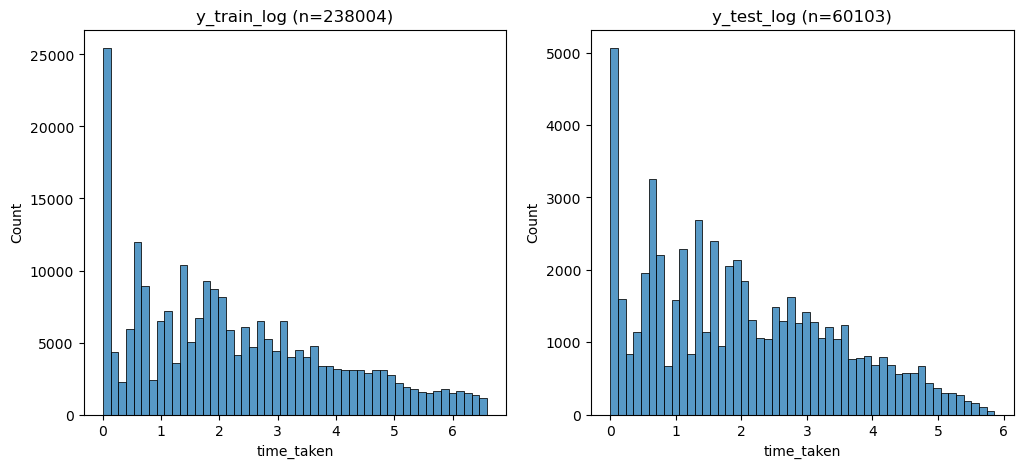

In [428]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(y_train_log, bins=50)
plt.title(f"y_train_log (n={len(y_train_log)})")

plt.subplot(122)
sns.histplot(y_test_log, bins=50)
plt.title(f"y_test_log (n={len(y_test_log)})")
plt.show()

In [397]:
# 标准化特征（仅对数值列）
numeric_cols = X_train_filtered.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

ValueError: could not convert string to float: 'Pittsburgh'

In [319]:
# 特征选择
selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# 获取保留的特征名
selected_features = numeric_cols[selector.get_support()]

In [320]:
selected_features

Index(['category', 'council_district', 'dept_simplified', 'neighborhood',
       'num_requests', 'police_zone', 'ward'],
      dtype='object')

3# 删除低频One-Hot特征（出现次数<50）
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)  # 保留方差>0.01的特征
X_train_selected = selector.fit_transform(X_train_filtered)
X_test_selected = selector.transform(X_test)

print(f"特征维度从{X_train.shape[1]}降至{X_train_selected.shape[1]}")

In [133]:
# Step 1: Select only numeric columns
numeric_cols = X_train.select_dtypes(include=['number']).columns
X_train_numeric = X_train[numeric_cols]

# Step 2: Apply variance threshold to numeric columns only
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_numeric)

# Step 3: Get columns to keep
selected_cols = numeric_cols[vt.get_support()]

# Step 4: Apply selection
X_train_selected = X_train_numeric[selected_cols]
X_test_selected = X_test[selected_cols]

# Check how many features were kept
print(f"Original numeric features: {len(numeric_cols)}")
print(f"Features after selection: {len(selected_cols)}")


Original numeric features: 18
Features after selection: 9


In [132]:
from sklearn.feature_selection import VarianceThreshold

# 基于训练集计算方差阈值（避免数据泄露）
selector = VarianceThreshold(threshold=0.01)  # 保留方差>0.01的特征
X_train_selected = selector.fit_transform(X_train_filtered)

# 获取被保留的特征名
selected_features = X_train_filtered.columns[selector.get_support()]

# 应用相同筛选到测试集
X_test_selected = selector.transform(X_test_raw[selected_features])

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


TypeError: Cannot cast DatetimeArray to dtype float64

In [79]:
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold(threshold=0.05)
#features = data_encoded.columns.difference(['time_taken', 'last_action_et','create_date_et', 'closed_date_et'])
X = pd.DataFrame(data_encoded)
vt.fit(X)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


TypeError: Cannot cast DatetimeArray to dtype float64

In [146]:
X_train_clean = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_clean = pd.DataFrame(X_test_selected, columns=selected_features)

# Lasso regression

In [262]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

In [321]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# 时间序列交叉验证（5折）
tss = TimeSeriesSplit(n_splits=5)

# 自动选择alpha
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 2, 100),  # 覆盖更广的alpha范围
    cv=tss,
    random_state=42,
    n_jobs=-1
)
lasso_cv.fit(X_train_scaled,y_train_log)

print(f"最优alpha: {lasso_cv.alpha_:.4f}")


最优alpha: 0.0534


In [322]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X, y_true):
    y_pred = model.predict(X)
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

# 训练集评估
train_metrics = evaluate_model(lasso_cv, X_train_scaled,y_train_log)

# 测试集评估
test_metrics = evaluate_model(lasso_cv, X_test_scaled, y_test_log)

print("训练集性能:")
print(pd.DataFrame([train_metrics]))
print("\n测试集性能:")
print(pd.DataFrame([test_metrics]))


训练集性能:
       RMSE       MAE        R2
0  1.550781  1.283882  0.103616

测试集性能:
       RMSE       MAE        R2
0  1.508478  1.258971  0.066668


In [ ]:
lasso_cv = LassoCV(
    alphas=4.6416,  # 覆盖更广的alpha范围
    cv=tss,
    random_state=42,
    n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)

In [339]:

from sklearn.model_selection import cross_validate

# 正确使用cross_validate支持多指标
metrics = cross_validate(
    lasso_cv,
    X_train_scaled,
    y_train_log,
    cv=TimeSeriesSplit(n_splits=5),
    scoring=['r2', 'neg_root_mean_squared_error'],
    return_train_score=True
)

print(f"交叉验证R²均值: {metrics['test_r2'].mean():.2f} ± {metrics['test_r2'].std():.2f}")
print(f"平均RMSE: {-metrics['test_neg_root_mean_squared_error'].mean():.2f}")


交叉验证R²均值: 0.06 ± 0.10
平均RMSE: 1.55


# XGBoost

In [323]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42
)

xgb.fit(X_train_selected, y_train_log)
y_pred_log = xgb.predict(X_test_selected)
y_pred = np.expm1(y_pred_log) 

print("XGBoost测试性能:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_log, y_pred_xgb_log)):.1f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")


XGBoost测试性能:
RMSE: 1.6
R²: 0.15


In [328]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8]
}

grid = GridSearchCV(
    XGBRegressor(n_estimators=1000, random_state=42),
    param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(X_train_selected, y_train_log)

print(f"最优参数: {grid.best_params_}")


最优参数: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 0.6}


In [332]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb = XGBRegressor(
    n_estimators=1000,
    colsample_bytree=0.6,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.6,
    random_state=42
)

xgb.fit(X_train_selected, y_train_log)
y_pred_log = xgb.predict(X_test_selected)
y_pred = np.expm1(y_pred_log) 

print("XGBoost测试性能:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_log, y_pred_xgb_log)):.1f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")


XGBoost测试性能:
RMSE: 1.6
R²: 0.11


In [335]:
from sklearn.model_selection import cross_validate

metrics = cross_validate(
    grid.best_estimator_,
    X_train_selected,
    y_train_log,
    cv=TimeSeriesSplit(n_splits=5),
    scoring=['r2', 'neg_root_mean_squared_error']
)

print(f"平均R²: {metrics['test_r2'].mean():.2f}")
print(f"平均RMSE: {-metrics['test_neg_root_mean_squared_error'].mean():.2f}")


平均R²: 0.18
平均RMSE: 1.46


In [261]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42
)

xgb.fit(X_train_selected, y_train_log)
y_pred_xgb_log = xgb.predict(X_test_selected)
#y_pred_xgb = np.expm1(y_pred_log) 

print("XGBoost测试性能:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_log, y_pred_xgb_log)):.1f}")
print(f"R²: {r2_score(y_test_log, y_pred_xgb_log):.2f}")

XGBoost测试性能:
RMSE: 1.6
R²: -0.11


In [240]:
# 计算基线均值预测的R²
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_filtered, y_train_log)
y_pred_dummy = dummy.predict(X_test)
r2_dummy = r2_score(y_test_log, y_pred_dummy)

print(f"基线均值R²: {r2_dummy:.2f}")

基线均值R²: -0.10


In [243]:
# 目标编码替代One-Hot
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=['neighborhood', 'dept_simplified', 'category'])
X_train_encoded = encoder.fit_transform(X_train_filtered, y_train_log)
X_test_encoded = encoder.transform(X_test)

# 部门响应时间统计特征
dept_stats = X_train.groupby('dept_simplified')['time_taken'].agg(['mean', 'std'])
X_train = X_train.merge(dept_stats, on='dept_simplified', suffixes=('', '_dept'))
X_test = X_test.merge(dept_stats, on='dept_simplified', suffixes=('', '_dept'))


ValueError: X does not contain the columns listed in cols

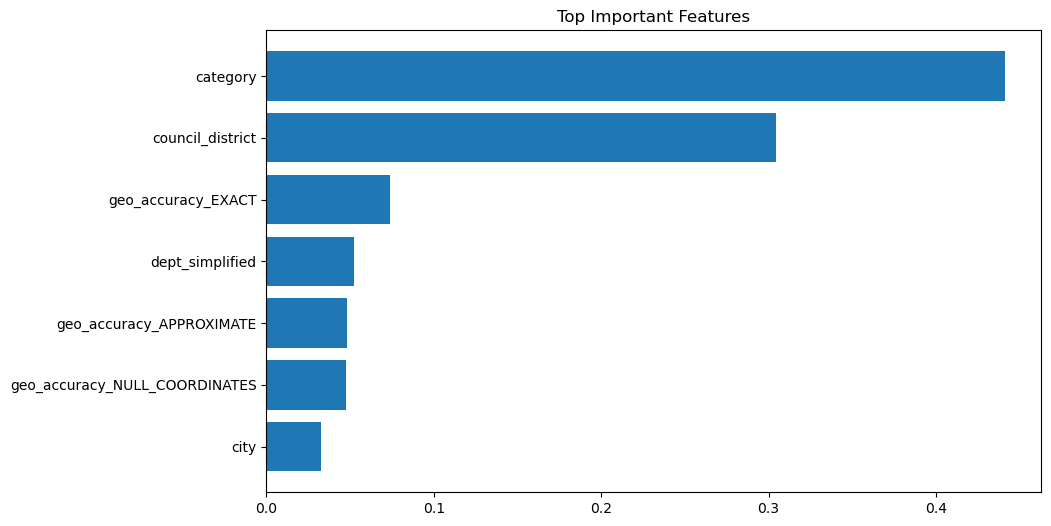

In [346]:
# 特征重要性可视化
importances = xgb.feature_importances_
sorted_idx = np.argsort(importances)[-20:]  # 取前20重要特征

plt.figure(figsize=(10,6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), features[sorted_idx])
plt.title("Top Important Features")
plt.show()


In [131]:
# 删除低频One-Hot特征（出现次数<50）
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # 保留方差>0.01的特征
X_train_selected = selector.fit_transform(X_train_filtered)
X_test_selected = selector.transform(X_test)

print(f"特征维度从{X_train.shape[1]}降至{X_train_selected.shape[1]}")


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


特征维度从318降至85


# RandomForest

In [452]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.8]
}

# 时间序列交叉验证
tscv = TimeSeriesSplit(n_splits=3)

# 初始化模型与搜索
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=2
)

# 执行搜索
grid_search.fit(X_train, y_train)

# ----------------------------
# 6. 最佳模型评估
# ----------------------------
# 获取最佳模型
best_rf = grid_search.best_estimator_

# 训练集评估
y_train_pred_log = best_rf.predict(X_train)
print("\n训练集性能:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_log)):.1f}")
print(f"R²: {r2_score(y_train, y_train_pred_log):.2f}")


# 测试集评估
y_test_pred_log = best_rf.predict(X_test)
print("\n测试集性能:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_log)):.1f}")
print(f"R²: {r2_score(y_test, y_test_pred_log):.2f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits


E:\anaconda\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   0.9s


E:\anaconda\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.8s


...

[CV] END max_depth=None, max_features=0.8, min_samples_split=5, n_estimators=200; total time=  23.1s


E:\anaconda\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



训练集性能:
RMSE: 1.4
R²: 0.28


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'Pittsburgh'

In [455]:
X_train_filtered['city']

435748    46.736873
291687    46.736873
353697    46.736873
263292    46.736873
443552    46.736873
            ...    
799995    46.736873
799997    46.736873
799994    46.736873
799993    46.736873
799999    46.736873
Name: city, Length: 297506, dtype: float64

In [351]:
# 转换所有稀疏布尔列为密集int类型
for col in X_train_selected.columns:
    if 'Sparse[bool, False]' in str(X_train_selected[col].dtype):
        X_train_selected[col] = X_train_selected[col].sparse.to_dense().astype(int)
        X_test_selected[col] = X_test_selected[col].sparse.to_dense().astype(int)
print("训练集特征类型:\n", X_train_selected.dtypes.value_counts())
print("\n测试集特征类型:\n", X_test_selected.dtypes.value_counts())
# 应只显示int64/float64


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

# LightGBM

In [347]:
# 转换所有稀疏布尔列为密集int类型（必须步骤）
for col in X_train_selected.columns:
    if 'Sparse[bool, False]' in str(X_train_selected[col].dtype):
        X_train_selected[col] = X_train_selected[col].sparse.to_dense().astype(int)
        X_test_selected[col] = X_test_selected[col].sparse.to_dense().astype(int)

# 定义需要显式声明为分类特征的列
cat_cols = ['dept_simplified', 'neighborhood', 'category', 'origin', 'geo_accuracy']

from category_encoders import TargetEncoder, OrdinalEncoder

# 对neighborhood做Target编码
te = TargetEncoder(cols=['neighborhood'])
X_train_encoded = te.fit_transform(X_train_selected, y_train)
X_test_encoded = te.transform(X_test_selected)

'''
# 对dept_simplified做Ordinal编码
ordinal_mapping = [
    {'col': 'dept_simplified', 
     'mapping': {'DPW': 0, 'Police': 1, 'DOMI': 2, ...}  # 按部门优先级定义
    }
]
oe = OrdinalEncoder(mapping=ordinal_mapping)
X_train_encoded = oe.fit_transform(X_train_encoded)
X_test_encoded = oe.transform(X_test_encoded)
'''

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
import lightgbm as lgb
from sklearn.preprocessing import OrdinalEncoder

# 处理分类列（LightGBM支持类别特征）
cat_cols = ['dept_simplified', 'neighborhood', 'category']
encoder = OrdinalEncoder()
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()
X_train_encoded[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test_encoded[cat_cols] = encoder.transform(X_test[cat_cols])

# 定义数据集
train_data = lgb.Dataset(X_train_encoded, label=y_train, categorical_feature=cat_cols)

# 参数设置
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'verbose': -1
}

# 交叉验证
cv_results = lgb.cv(
    params,
    train_data,
    num_boost_round=1000,
    nfold=5,
    stratified=False,
    shuffle=False,  # 保持时间顺序
    early_stopping_rounds=50
)

# 正式训练
best_round = len(cv_results['rmse-mean'])
model_lgb = lgb.train(params, train_data, num_boost_round=best_round)

# 评估
y_pred_lgb = model_lgb.predict(X_test_encoded)
print(f"LightGBM测试性能:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lgb)):.1f}")
print(f"R²: {r2_score(y_test, y_pred_lgb):.2f}")
